# Астафьев Никита - БПИ242
# Брыкин Егор - БПИ242

# Исследование оттока клиентов телеком-компании (Telco Customer Churn)

## Введение

В условиях высокой конкуренции на рынке телекоммуникационных услуг удержание существующих клиентов становится для компаний приоритетной задачей, зачастую более важной, чем привлечение новых. Стоимость привлечения нового абонента в несколько раз превышает затраты на удержание текущего, поэтому снижение уровня оттока (Churn Rate) напрямую влияет на прибыль и устойчивость бизнеса.

Целью данного исследования является анализ данных о клиентах вымышленной телеком-компании для выявления ключевых причин ухода абонентов и построения модели, прогнозирующей риск оттока.

## О датасете

Для анализа используется набор данных **WA_Fn-UseC_-Telco-Customer-Churn**, доступный на платформе Kaggle. Датасет содержит информацию о 7043 клиентах и включает в себя 21 признак, описывающий:
*   **Демографию:** пол, возраст (пенсионер/нет), наличие партнера и иждивенцев.
*   **Услуги:** телефония, интернет (DSL/Fiber optic), потоковое ТВ, защита устройств и т.д.
*   **Финансы:** тип контракта, способ оплаты, ежемесячные и общие платежи.
*   **Целевую переменную:** `Churn` (ушел ли клиент из компании за последний месяц).

## План исследования

Работа состоит из следующих этапов:
1.  **Загрузка и первичный осмотр данных:** Оценка размерности, типов данных и пропусков.
2.  **Предобработка (Data Cleaning):** Исправление некорректных значений (например, пробелы в числовых столбцах) и приведение типов данных к подходящему виду.
3.  **Разведочный анализ данных (EDA):** Визуализация распределений, поиск аномалий и первичных закономерностей.
4.  **Проверка гипотез:** Статистическое тестирование предположений о влиянии различных факторов на отток.
5.  **Моделирование:** Построение регрессионных моделей для оценки влияния признаков и прогнозирования оттока.
6.  **Кластерный анализ:** Сегментация клиентской базы для выявления типичных профилей пользователей.
7.  **Выводы и рекомендации:** Формирование итоговых заключений и предложений для бизнеса.

In [1]:
%pip install -r requirements.txt

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [3]:
from pathlib import Path

class AmbiguityError(Exception):
    """Невозможно однозначно определить результат"""
    pass

def get_dataset_path(possible_paths: list[Path]) -> Path:
    """
    Проверяет все пути, указанные в `possible_paths` на существование.

    :param possible_paths: Пути для проверки на наличие датасета
    :raises AmbiguityError: Если обнаружено несколько файлов
    :returns: Путь к файлу датасета
    """

    present_files: list[Path] = [p for p in possible_paths if p.exists()]

    if len(present_files) > 1:
        error_message: str = "Multiple path provided exist:\n"
        for i, path in enumerate(present_files, 1):
            error_message += f"{i}: {path}\n"
        raise AmbiguityError(error_message)

    if len(present_files) == 0:
        raise FileNotFoundError("Dataset not found.")

    return present_files[0]

## 1. Загрузка датасета

In [4]:
import os

DATASET_FILENAME: Path = Path("Customer-Churn.csv")
DATASETS_DIR: Path = Path("datasets")
os.makedirs(DATASETS_DIR, exist_ok=True)

df_path: Path = get_dataset_path([
    DATASET_FILENAME,
    DATASETS_DIR / DATASET_FILENAME
])

df_original: pd.DataFrame = pd.read_csv(df_path)

## 2. Первичное описание датасета

In [5]:
SECTION_HEADER_LENGTH: int = 60
SECTION_HEADER_FILLER: str = '='
assert len(SECTION_HEADER_FILLER) == 1, "SECTION_HEADER_FILLER должен быть символом"

def print_section_header(section_name: str, enable_top_padding: bool = True, length: int = SECTION_HEADER_LENGTH):
    inner_text: str = f" {section_name} "
    if enable_top_padding:
        print()
    print(inner_text.center(length, SECTION_HEADER_FILLER))

In [6]:
print_section_header("Размерность датасета", False)
initial_df_shape: tuple[int, int] = df_original.shape
print(f"Уникальных значений: {initial_df_shape[0]}")
print(f"Число переменных: {initial_df_shape[1]}")

print_section_header("Пропущенные значения")

# Заменим пустые строки на NaN
df_original = df_original.map(lambda x: x.strip() if isinstance(x, str) else x)
df_original.replace("", np.nan, inplace=True);

total_na_cnt: int = 0
for col_name in df_original:
    na_cnt: int = df_original[col_name].isna().sum()
    if na_cnt == 0:
        continue
    print(f"{col_name}: {na_cnt}")
    total_na_cnt += na_cnt
print(f"\nВсего пропущенных значений: {total_na_cnt}")

=================== Размерность датасета ===================
Уникальных значений: 7043
Число переменных: 21

=================== Пропущенные значения ===================
TotalCharges: 11

Всего пропущенных значений: 11


Видим наличие Na в числе 11 штук (изначально представлены пустыми строками вместо чисел)

В связи с их незначительным силом (11 / 7024 = 0.16%) удалим их

In [7]:
df_original = df_original.dropna()

assert df_original.isna().sum().sum() == 0 and len(df_original) == initial_df_shape[0] - 11, "В таблице остались NaN или были удалены нерассмотренные значения"

In [8]:
print_section_header("Типы", False)
df_original.info()

=========================== Типы ===========================
<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   str    
 1   gender            7032 non-null   str    
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   str    
 4   Dependents        7032 non-null   str    
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   str    
 7   MultipleLines     7032 non-null   str    
 8   InternetService   7032 non-null   str    
 9   OnlineSecurity    7032 non-null   str    
 10  OnlineBackup      7032 non-null   str    
 11  DeviceProtection  7032 non-null   str    
 12  TechSupport       7032 non-null   str    
 13  StreamingTV       7032 non-null   str    
 14  StreamingMovies   7032 non-null   str    
 15  Contract          7032 non-null   str    
 1

# Описание датасета

|Название признака| Что измеряет | Тип признака |
|---|--|--|
|customerID | Уникальный идентификатор клиента | Номинальный (ID)
|gender|Пол клиента (Male/Female)|Категориальный (Бинарный/Номинальный)
|SeniorCitizen|Является ли клиент пенсионером (0/1)|Категориальный (Бинарный)
|Partner|Есть ли у клиента партнер/супруг (Yes/No)|Категориальный (Бинарный)
|Dependents|Есть ли у клиента иждивенцы (Yes/No)|Категориальный (Бинарный)
|tenure|Сколько месяцев клиент пользуется услугами (месяцы)|Метрический (Дискретный)
|PhoneService|Подключена ли телефонная услуга (Yes/No)|Категориальный (Бинарный)
|MultipleLines|Подключено ли несколько линий (Yes/No/No phone service)|Категориальный (Номинальный)
|InternetService|Тип интернет-провайдера (DSL/Fiber optic/No)|Категориальный (Номинальный)
|OnlineSecurity|Подключена ли онлайн-защита (Yes/No/No internet service)|Категориальный (Номинальный)
|OnlineBackup|Подключен ли онлайн-бэкап (Yes/No/No internet service)|Категориальный (Номинальный)
|DeviceProtection|Есть ли защита устройств (Yes/No/No internet service)|Категориальный (Номинальный)
|TechSupport|Есть ли техподдержка (Yes/No/No internet service)|Категориальный (Номинальный)
|StreamingTV|Есть ли потоковое ТВ (Yes/No/No internet service)|Категориальный (Номинальный)
|StreamingMovies|Есть ли потоковое кино (Yes/No/No internet service)|Категориальный (Номинальный)
|Contract|Тип контракта (Month-to-month/One year/Two year)|Категориальный (Порядковый)
|PaperlessBilling|Используется ли безбумажный счет (Yes/No)|Категориальный (Бинарный)
|PaymentMethod|Метод оплаты (Electronic check и др.)|Категориальный (Номинальный)
|MonthlyCharges|Ежемесячная плата (доллары)|Метрический (Непрерывный)
|TotalCharges|Общая сумма за все время (доллары)|Метрический (Непрерывный)
|Churn|Ушел ли клиент (Yes/No) — Целевая переменная|Категориальный (Бинарный)


# 3. Нормализация данных

Часть переменных, имеющих два значения, закодирована текстом ("Yes" / "No"). Преобразуем их в числовой формат.

Переменные с тремя и более категориями ("Yes" / "No" / прочие варианты) пока оставим без изменений.

In [9]:
BOOL_REPR: str = "int8"

df_binary_normalization: pd.DataFrame = df_original.copy()
binary_mappings: dict[str, bool] = { "yes": True, "no": False }

def binary_str_to_bool(s: str) -> bool:
    s_lowercase: str = s.lower()
    if s_lowercase in binary_mappings.keys():
        return binary_mappings[s_lowercase]
    raise RuntimeError(f"Unexpected value '{s}'. Possible values: {', '.join(list(binary_mappings.keys()))}")

for col_name in df_original:
    if df_original[col_name].dtype != "str":
        continue
    normalized_unique_column_values: list = list(map(lambda x: x.lower(), df_original[col_name].unique()))

    # Преобразуем yes/no в boolean, остальное в категории
    if sorted(normalized_unique_column_values) == ["no", "yes"]:
        df_binary_normalization[col_name] = df_binary_normalization[col_name].map(binary_str_to_bool).astype(BOOL_REPR)
    elif len(normalized_unique_column_values) <= 4:
        df_binary_normalization[col_name] = df_binary_normalization[col_name].astype("category")

# Создаем бинарный признак isMale из gender
df_binary_normalization["isMale"] = df_original["gender"].map(lambda x: x.lower() == "male").astype(BOOL_REPR)
df_binary_normalization.drop(columns=["gender"], inplace=True)

In [10]:
print(f"Максимальное значение 'tenure': {df_original["tenure"].max()}")
print(f"Максимальное значение 'MonthlyCharges': {df_original["MonthlyCharges"].max()}")

Максимальное значение 'tenure': 72
Максимальное значение 'MonthlyCharges': 118.75


In [11]:
# Сделаем явную проверку, что тип приводим. В случае, если это не так to_numeric бросит ошибку
df_binary_normalization['TotalCharges'] = pd.to_numeric(df_original['TotalCharges'])
df_binary_normalization = df_binary_normalization.astype({
    "tenure": "int32",
    "SeniorCitizen": BOOL_REPR,
    "MonthlyCharges": "float32",
    "TotalCharges": "float32"
})

In [12]:
df_binary_normalization.dtypes

customerID               str
SeniorCitizen           int8
Partner                 int8
Dependents              int8
tenure                 int32
PhoneService            int8
MultipleLines       category
InternetService     category
OnlineSecurity      category
OnlineBackup        category
DeviceProtection    category
TechSupport         category
StreamingTV         category
StreamingMovies     category
Contract            category
PaperlessBilling        int8
PaymentMethod       category
MonthlyCharges       float32
TotalCharges         float32
Churn                   int8
isMale                  int8
dtype: object

In [13]:
NORMALIZED_DATASET_FILENAME: str = "customer-churn-normalized.csv"
df_binary_normalization.to_csv(DATASETS_DIR / NORMALIZED_DATASET_FILENAME)

# Будем работать с нормализованной версией
df = df_binary_normalization
df.set_index("customerID", inplace=True);

## 4. Расчет нового столбца

In [14]:
# Создадим признак "Средний чек за месяц"
df["avgChargePerMonth"] = df.apply(lambda row: row['TotalCharges'] / row['tenure'], axis=1)

## 5. Рекодирование метрики

Создадим категориальную переменную новизны клиентов на основе 25-го и 75-го процентилей

In [15]:
bins: list[float] = [0.0, df["tenure"].quantile(0.25), df["tenure"].quantile(0.75), df["tenure"].max()]
labels: list[str] = ["Новые клиенты", "Постоянные клиенты", "Долгосрочные клиенты"]

df['TenureGroup'] = pd.cut(df['tenure'], bins=bins, labels=labels, include_lowest=True).astype('category')

In [16]:
print_section_header("Первые значения таблицы")
df.head()


================= Первые значения таблицы ==================


,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,isMale,avgChargePerMonth,TenureGroup
customerID,,,,,,,,,,,,,,,,,,,,,
7590-VHVEG,0,1,0,1,0,No phone service,DSL,No,Yes,No,...,No,Month-to-month,1,Electronic check,29.850000,29.850000,0,0,29.850000,Новые клиенты
5575-GNVDE,0,0,0,34,1,No,DSL,Yes,No,Yes,...,No,One year,0,Mailed check,56.950001,1889.500000,0,1,55.573529,Постоянные клиенты
3668-QPYBK,0,0,0,2,1,No,DSL,Yes,Yes,No,...,No,Month-to-month,1,Mailed check,53.849998,108.150002,1,1,54.075001,Новые клиенты
7795-CFOCW,0,0,0,45,0,No phone service,DSL,Yes,No,Yes,...,No,One year,0,Bank transfer (automatic),42.299999,1840.750000,0,1,40.905556,Постоянные клиенты
9237-HQITU,0,0,0,2,1,No,Fiber optic,No,No,No,...,No,Month-to-month,1,Electronic check,70.699997,151.649994,1,0,75.824997,Новые клиенты


# 6. Цель и задачи исследования

**Цель исследования:**
Выявить ключевые факторы, влияющие на отток клиентов (Churn) телеком-компании, и разработать модель для прогнозирования вероятности ухода клиента.

**Задачи исследования:**
1. **Провести разведочный анализ данных (EDA):** Очистить данные, проанализировать распределения признаков и выявить аномалии.
2. **Сформировать портрет уходящего клиента:** Описать социально-демографические и поведенческие характеристики клиентов, которые чаще всего расторгают контракт.
3. **Проверить статистические гипотезы:** Подтвердить или опровергнуть предположения о влиянии различных услуг и условий контракта на отток.
4. **Построить прогнозные модели:** Разработать модели классификации для оценки риска оттока.
5. **Сегментировать клиентов:** Провести кластеризацию для выделения групп клиентов со схожим поведением.

# 7. Исследовательские гипотезы и методы их проверки

| № | Гипотеза | Типы переменных | Метод проверки | Обоснование метода |
| :--- | :--- | :--- | :--- | :--- |
| **1** | Клиенты с помесечным контрактом (`Contract` = Month-to-month) уходят чаще. | Категориальная vs Категориальная | **Тест Хи-квадрат** | Хи-квадрат проверяет значимость связи. |
| **2** | Наличие оптоволокна (`InternetService` = Fiber optic) повышает риск оттока. | Категориальная vs Категориальная | **Логистическая регрессия** | Позволяет отделить эффект типа интернета от эффекта цены. |
| **3** | Клиенты старше 65 лет (`SeniorCitizen` = 1) уходят реже. | Бинарная vs Бинарная | **Тест Хи-квадрат** | Проверяем значимость различия долей оттока. |
| **4** | Высокая ежемесячная плата (`MonthlyCharges`) коррелирует с оттоком. | Числовая vs Бинарная | **T-тест Стьюдента** (или **U-тест**) | Сравниваем средние платы в группах. |
| **5** | Клиенты без технической поддержки (`TechSupport` = No) уходят чаще. | Категориальная vs Категориальная | **Тест Хи-квадрат** | Хи-квадрат проверяет значимость связи. |
| **6** | Способ оплаты электронным чеком (`PaymentMethod` = Electronic check) связан с высоким оттоком. | Категориальная vs Категориальная | **Тест Хи-квадрат** | Хи-квадрат проверяет значимость связи. |
| **7** | Клиенты с партнером (`Partner` = Yes) или зависимыми (`Dependents` = Yes) уходят реже. | 2x Бинарная vs Бинарная | **Множественная логистическая регрессия** | Регрессия даст количественную оценку влияния. |
| **8** | Чем дольше клиент с компанией (`tenure`), тем ниже риск оттока. | Числовая vs Бинарная | **Логистическая регрессия** | Оценим, как изменение tenure на 1 месяц влияет на логарифм шансов оттока. |
| **9** | Наличие доп. услуг (`OnlineSecurity` = Yes и т.д.) снижает отток. | Множественные бинарные vs Бинарная | **Множественная логистическая регрессия** | Оценим независимый вклад каждой услуги. |
| **10** | `tenure` и `MonthlyCharges` коррелируют (клиенты со стажем имеют другие тарифы) | Числовая vs Числовая | **Корреляция Пирсона** (или **Спирмена**) | Позволяет оценить силу и направление линейной связи между переменными. |

## 8. Построение графиков

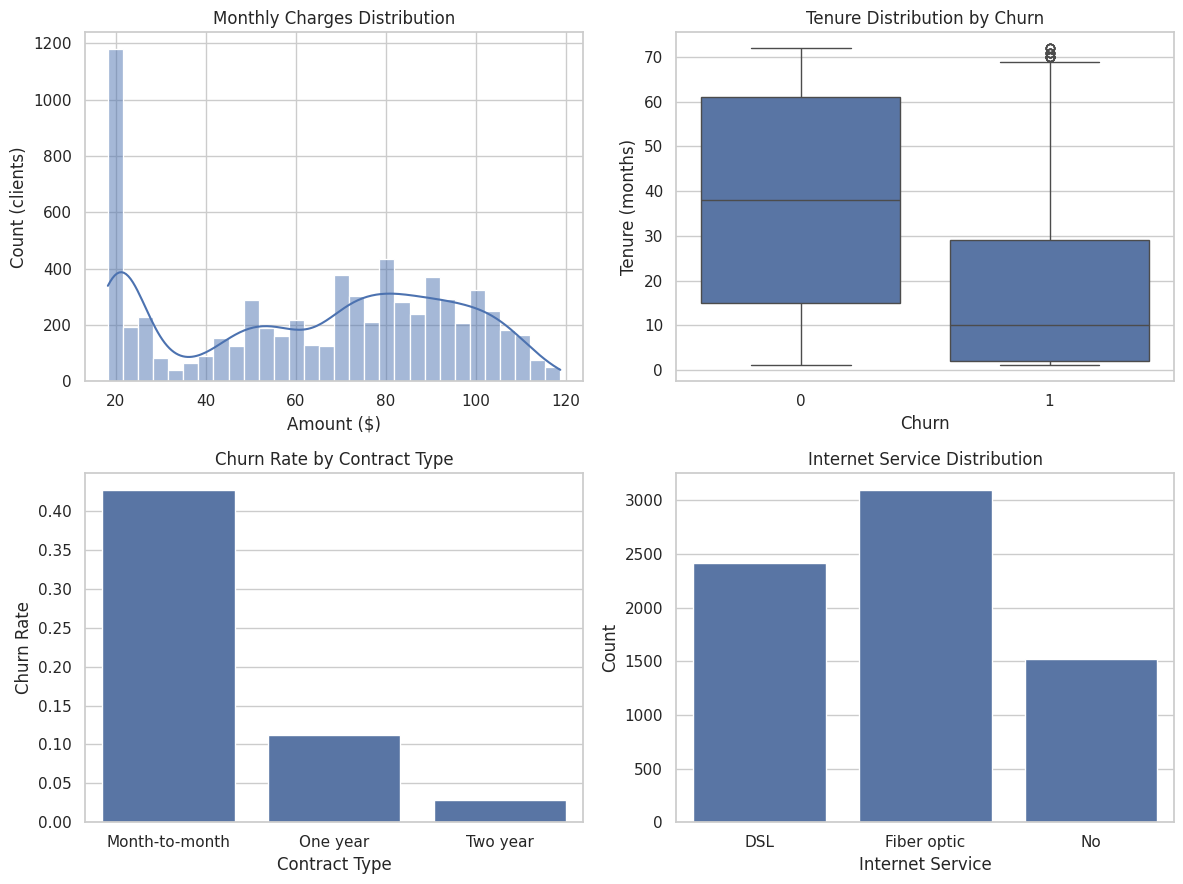

In [17]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

sns.histplot(
    data=df,
    x="MonthlyCharges",
    bins=30,
    kde=True,
    ax=axes[0, 0]
)
axes[0, 0].set(
    title="Monthly Charges Distribution",
    xlabel="Amount ($)",
    ylabel="Count (clients)"
)


sns.boxplot(
    data=df,
    x="Churn",
    y="tenure",
    ax=axes[0, 1]
)
axes[0, 1].set(
    title="Tenure Distribution by Churn",
    xlabel="Churn",
    ylabel="Tenure (months)"
)


sns.barplot(
    data=df,
    x="Contract",
    y=df["Churn"],
    estimator="mean",
    errorbar=None,
    ax=axes[1, 0]
)
axes[1, 0].set(
    title="Churn Rate by Contract Type",
    xlabel="Contract Type",
    ylabel="Churn Rate"
)


sns.countplot(
    data=df,
    x="InternetService",
    ax=axes[1, 1]
)
axes[1, 1].set(
    title="Internet Service Distribution",
    xlabel="Internet Service",
    ylabel="Count"
)

plt.tight_layout()
plt.show()

**Комментарии к графикам:**

**1. Гистограмма - Распределение ежемесячных платежей:**
Распределение имеет два пика. Первый высокий пик находится в районе **\$20** (базовые тарифы), а второй, более широкий, располагается в диапазоне **\$70–\$100**. Это указывает на то, что клиентскую базу можно разбить на две группы: пользователи дешевых услуг и пользователи дорогих пакетов.

**2. Boxplot - Распределение срока обслуживания по факту оттока:**
Наблюдается сильная обратная зависимость между сроком обслуживания и оттоком.
*   Клиенты, которые ушли от оператора, имеют значительно меньший срок обслуживания (медиана около 10 месяцев).
*   Лояльные клиенты остаются с компанией гораздо дольше (медиана около 38 месяцев).
Вывод: Риск оттока наиболее высок в первый год пользования услугами.

**3. Bar plot - Уровень оттока по типам контракта:**
Наблюдается критическая зависимость оттока от типа контракта.
*   Клиенты с контрактом **Month-to-month** уходят чаще всего — доля оттока превышает **40%**.
*   Долгосрочные обязательства эффективно удерживают клиентов: отток падает до **\~11%** для контрактов на год и до минимума (**\<3%**) для контрактов на два года

**4. Count plot - Количество клиентов по типу интернета:**
Самой популярной услугой является **Fiber optic** (средний столбец) — ею пользуется более **3000 клиентов**. Услуга DSL популярна чуть меньше (\~2400 клиентов), а около 1500 клиентов не подключают интернет вовсе.

In [18]:
BINS_CNT: int = 15

graph_df: pd.DataFrame = df.copy()
graph_df['tenure_bin'] = pd.cut(graph_df['tenure'], bins=BINS_CNT, labels=False, include_lowest=True)
graph_df['charges_bin'] = pd.cut(graph_df['MonthlyCharges'], bins=BINS_CNT, labels=False, include_lowest=True)

grouped: pd.DataFrame = graph_df.groupby(['tenure_bin', 'charges_bin']).agg(
    total_count=('Churn', 'count'),
    churned_count=('Churn', lambda x: (x == 1).sum())
).reset_index()

total_churned: int = graph_df[graph_df['Churn'] == 1].shape[0]
grouped['contribution_to_total'] = grouped['churned_count'] / total_churned * 100

grouped['churn_rate'] = grouped['churned_count'] / grouped['total_count'] * 100

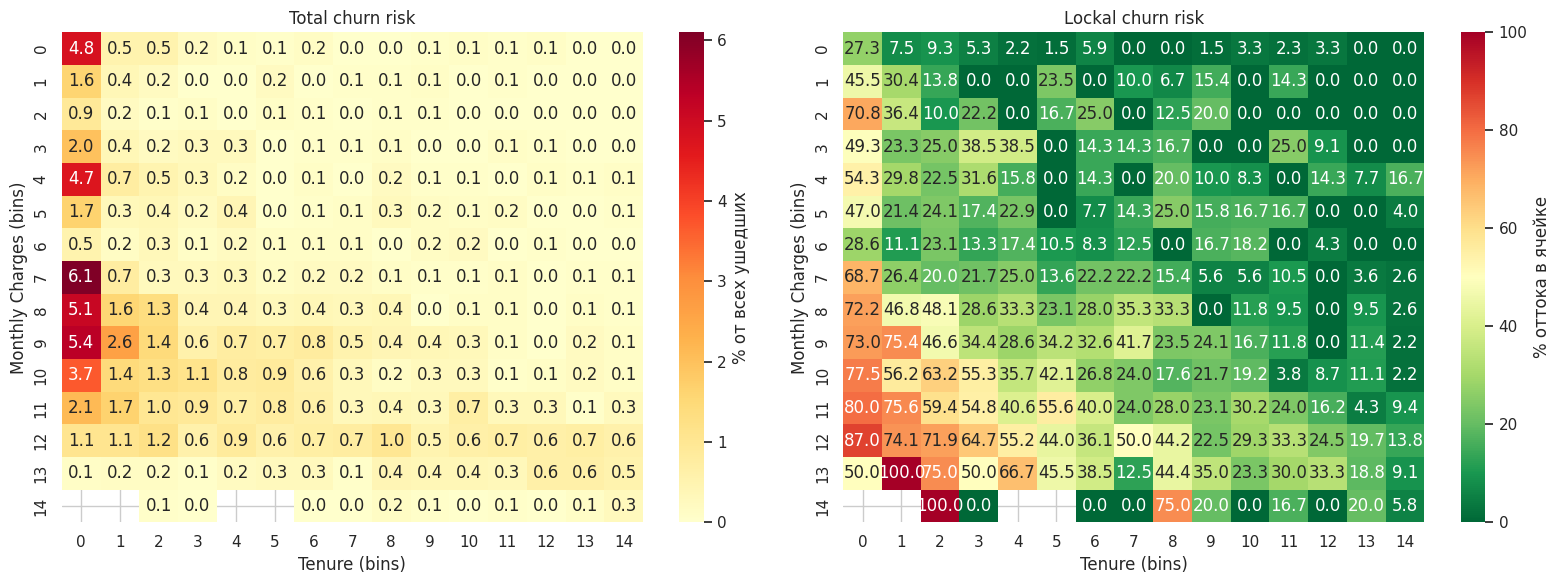

In [19]:
def create_heatmap_data(grouped: pd.DataFrame, value_col: str) -> pd.DataFrame:
    """
    Преобразует агрегированные данные в матрицу для heatmap.

    :returns: DataFrame в формате матрицы (pivot table)
    """
    heatmap_data = grouped.pivot(
        index='charges_bin',
        columns='tenure_bin',
        values=value_col
    )
    return heatmap_data

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

heatmap1 = create_heatmap_data(grouped, 'contribution_to_total')
sns.heatmap(
    heatmap1,
    ax=axes[0],
    cmap='YlOrRd',
    annot=True,
    fmt='.1f',
    cbar_kws={'label': '% от всех ушедших'}
)
axes[0].set(
    title="Total churn risk",
    xlabel="Tenure (bins)",
    ylabel="Monthly Charges (bins)"
)

heatmap2 = create_heatmap_data(grouped, 'churn_rate')
sns.heatmap(
    heatmap2,
    ax=axes[1],
    cmap='RdYlGn_r',
    annot=True,
    fmt='.1f',
    cbar_kws={'label': '% оттока в ячейке'}
)
axes[1].set(
    title="Lockal churn risk",
    xlabel="Tenure (bins)",
    ylabel="Monthly Charges (bins)"
)

plt.tight_layout()
plt.show()

**Комментарии к графикам:**

**1. Heatmap - Общий риск оттока:**
Эта карта показывает, где находится наибольшее количество ушедших клиентов (в абсолютных цифрах).

* Самые «горячие» зоны сосредоточены в левом нижнем углу. Это означает, что основная масса оттока приходится на клиентов с высокими ежемесячными платежами (бины 7–10) и коротким сроком обслуживания (бины 0–2).
* Компания теряет больше всего денег именно на новых клиентах с дорогими тарифами.

**2. Heatmap - Локальный риск оттока:**
Эта карта показывает вероятность ухода внутри конкретной группы
Мы видим экстремально высокие значения риска для клиентов с высокими счетами и малым сроком службы.

* Также интересно отметить аномалию: 100% отток в группе давних клиентов (бин 13) со средним чеком (бин 7), что может указывать на специфическую проблему с этим тарифом для старожилов.

## 9. Тест Хи-квадрат

In [20]:
from itertools import chain

def is_chi2_ready(df_to_check: pd.DataFrame) -> bool:
    """
    Проверяет, что к датасету применим тест Хи квадрат.

    Для 95% или более ячеек должно быть верно: expected value > 5.

    :param df_to_check: Датасет для проверки
    :returns: Применим ли Хи квадрат
    """

    is_expected_value_geq_5: list[bool] = list(chain(*(stats.chi2_contingency(df_to_check)[3] > 5))) # pyright: ignore[reportOperatorIssue]
    expected_value_geq_5_pct: float = sum(is_expected_value_geq_5) / len(is_expected_value_geq_5)
    return bool(expected_value_geq_5_pct >= 0.95)

def run_chi2(col1: str, col2: str) -> None:
    """
    Запускает тест Хи квадрат

    :displays: результат теста, если он применим
    """

    pivot: pd.DataFrame = pd.crosstab(df[col1], df[col2], margins=True, normalize='index') * 100
    print_section_header(f"{col1} vs {col2}")
    display(pivot.round(2))

    contingency: pd.DataFrame = pd.crosstab(df[col1], df[col2])
    if not is_chi2_ready(contingency):
        print(f"{col1} and {col2} are not valid for chi2 test")
        return

    chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
    print(f"\nТест Хи-квадрат ({col1} vs {col2}):")
    print(f"Хи-квадрат статистика: {chi2:.4f}")
    print(f"P-value: {p_value:.4e}")
    print(f"Степени свободы: {dof}")

**Гипотеза 1** - Клиенты с помесечным контрактом (`Contract` = `Month-to-month`) уходят чаще.

In [21]:
run_chi2('Contract', 'Churn')


==================== Contract vs Churn =====================


Churn,0,1
Contract,,
Month-to-month,57.29,42.71
One year,88.72,11.28
Two year,97.15,2.85
All,73.42,26.58



Тест Хи-квадрат (Contract vs Churn):
Хи-квадрат статистика: 1179.5458
P-value: 7.3262e-257
Степени свободы: 2


Наблюдается очень сильная обратная зависимость между длительностью контракта и оттоком клиентов. Клиенты с **помесячным контрактом** уходят крайне часто (**42.71%**), тогда как клиенты, заключившие договор на два года, почти никогда не уходят (всего **2.85%**). Чем дольше срок обязательства по контракту, тем ниже риск оттока.

**Тест Хи-квадрат:**
*   **Гипотезы:**
    *   $H_0$ (Нулевая гипотеза): Тип контракта и Отток независимы (связи нет).
    *   $H_1$ (Альтернативная гипотеза): Тип контракта и Отток зависимы (связь есть).
*   **Вывод:** Так как P-value чрезвычайно мало ($p < 0.05$), мы **отклоняем нулевую гипотезу ($H_0$)**. Между типом контракта и оттоком клиентов существует статистически значимая взаимосвязь.


**Гипотеза 3** - Клиенты старше 65 лет (SeniorCitizen = 1) уходят реже.

In [22]:
run_chi2('SeniorCitizen', 'Churn')


================== SeniorCitizen vs Churn ==================


Churn,0,1
SeniorCitizen,,
0,76.35,23.65
1,58.32,41.68
All,73.42,26.58



Тест Хи-квадрат (SeniorCitizen vs Churn):
Хи-квадрат статистика: 158.4408
P-value: 2.4793e-36
Степени свободы: 1


Уровень оттока среди пожилых клиентов составляет **41.68%**, в то время как среди остальных клиентов он почти в два раза ниже — **23.65%**. Возраст является важным фактором риска оттока.

**Тест Хи-квадрат:**
*   **Гипотезы:**
    *   $H_0$ (Нулевая гипотеза): Статус пенсионера и Отток независимы (связи нет).
    *   $H_1$ (Альтернативная гипотеза): Статус пенсионера и Отток зависимы (связь есть).
*   **Вывод:** Так как P-value чрезвычайно мало ($p < 0.05$), мы **отклоняем нулевую гипотезу ($H_0$)**. Существует статистически значимая взаимосвязь: пожилые клиенты склонны уходить из компании чаще.

**Гипотеза 5** - Клиенты без технической поддержки (TechSupport = No) уходят чаще.

In [23]:
run_chi2('TechSupport', 'Churn')


=================== TechSupport vs Churn ===================


Churn,0,1
TechSupport,,
No,58.35,41.65
No internet service,92.57,7.43
Yes,84.80,15.20
All,73.42,26.58



Тест Хи-квадрат (TechSupport vs Churn):
Хи-квадрат статистика: 824.9256
P-value: 7.4078e-180
Степени свободы: 2


Клиенты, у которых **нет технической поддержки** (`No`), демонстрируют самый высокий уровень оттока среди всех групп — **41.65%**. Наличие поддержки (`Yes`) существенно снижает этот риск до **15.20%**.
Отдельно стоит отметить группу `No internet service` (вероятно, клиенты только с телефонией), у которых отток минимален (**7.43%**).

**Тест Хи-квадрат:**
*   **Гипотезы:**
    *   $H_0$ (Нулевая гипотеза): Наличие техподдержки и Отток независимы.
    *   $H_1$ (Альтернативная гипотеза): Наличие техподдержки и Отток зависимы.
*   **Вывод:** Так как P-value чрезвычайно мало ($p < 0.05$), мы **отклоняем нулевую гипотезу ($H_0$)**. Существует статистически значимая взаимосвязь между наличием технической поддержки и оттоком клиентов.

**Гипотеза 6** - Способ оплаты электронным чеком (PaymentMethod = Electronic check) связан с высоким оттоком.

In [24]:
run_chi2('PaymentMethod', 'Churn')


================== PaymentMethod vs Churn ==================


Churn,0,1
PaymentMethod,,
Bank transfer (automatic),83.27,16.73
Credit card (automatic),84.75,15.25
Electronic check,54.71,45.29
Mailed check,80.80,19.20
All,73.42,26.58



Тест Хи-квадрат (PaymentMethod vs Churn):
Хи-квадрат статистика: 645.4299
P-value: 1.4263e-139
Степени свободы: 3


Способ оплаты **«Electronic check»** является явным лидером по оттоку клиентов — **45.29%** пользователей с этим методом оплаты уходят. Это почти в три раза выше, чем у автоматических способов оплаты (Bank transfer и Credit card), где отток составляет всего около **15-16%**. Даже оплата чеком по почте (Mailed check) показывает значительно лучшие результаты (\~19%). Можно сделать вывод, что автоматические платежи удерживают клиентов, а ручная оплата через электронные чеки связана с высоким риском ухода.

**Тест Хи-квадрат:**
*   **Гипотезы:**
    *   $H_0$ (Нулевая гипотеза): Способ оплаты и Отток независимы.
    *   $H_1$ (Альтернативная гипотеза): Способ оплаты и Отток зависимы.
*   **Вывод:** Так как P-value чрезвычайно мало ($p < 0.05$), мы **отклоняем нулевую гипотезу ($H_0$)**. Существует статистически значимая взаимосвязь между способом оплаты и оттоком клиентов.

### Т-тест 4 гипотезы -  Высокая ежемесячная плата (`MonthlyCharges`) коррелирует с оттоком.

In [25]:
churn_yes: pd.DataFrame = df[df['Churn'] == 1]['MonthlyCharges']
churn_no: pd.DataFrame = df[df['Churn'] == 0]['MonthlyCharges']

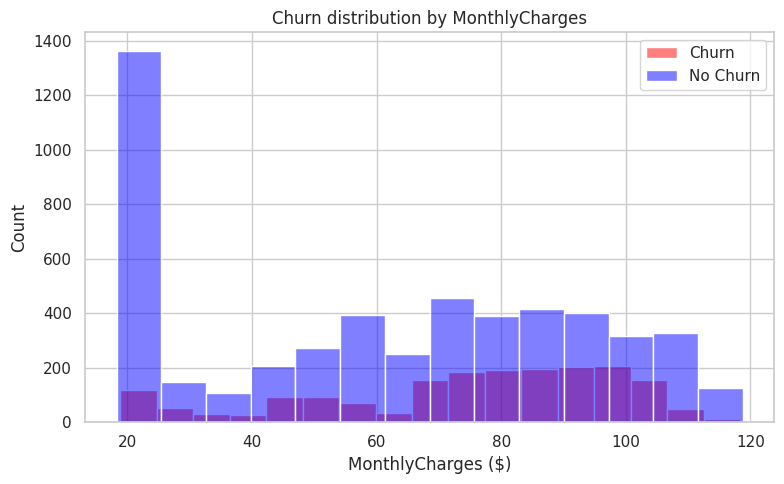

In [85]:
plt.figure(figsize=(8, 5))

sns.histplot(churn_yes, label='Churn', alpha=0.5, color='red')
sns.histplot(churn_no, label='No Churn', alpha=0.5, color='blue')
plt.xlabel('MonthlyCharges ($)')
plt.legend()
plt.title('Churn distribution by MonthlyCharges')

plt.tight_layout()
plt.show()

### Определим нормальность распределения для проведения теста

In [27]:
def run_nd_test(column: pd.Series, column_name: str | None = None, plot_dist: bool = True, print_result: bool = True) -> float:
    """
    Выполняет тест на нормальное распределение.

    Используется либо тест Колмогорова-Смирнова, либо тест Шапира-Уилка
    в зависимости от размера входных данных

    :param column: Столбец для которого надо применить тест
    :param column_name: Название столбца. Используется для логирования
    :param plot_dist: Требуется ли построить график распределения переменной
    :param print_result: Требуется ли напечатать результат в консоль
    :returns: Полученное p-value
    """

    column_no_na: pd.Series = column.dropna()

    if len(column_no_na) >= 50:
        p_value: np.float64 = stats.kstest(column_no_na, 'norm', args=(column_no_na.mean(), column_no_na.std()))[1]
    else:
        p_value: np.float64 = stats.shapiro(column_no_na)[1]

    if print_result:
        print(f"Тест на нормальность распределение", end="")
        if column_name:
            print(f"для столбца {column_name}", end="")
        print(f". p-value: {p_value:.5}")
    if plot_dist:
        plt.figure()
        sns.histplot(column_no_na.to_frame(), kde=True)
    return p_value

In [28]:
run_nd_test(churn_yes, column_name='Ушедшие клиенты', plot_dist=False, print_result=True)
run_nd_test(churn_no, column_name='Оставшиеся клиенты', plot_dist=False, print_result=True);

Тест на нормальность распределениедля столбца Ушедшие клиенты. p-value: 1.2573e-26
Тест на нормальность распределениедля столбца Оставшиеся клиенты. p-value: 0.0


Тест подтверждает, что оба распределения не нормальны

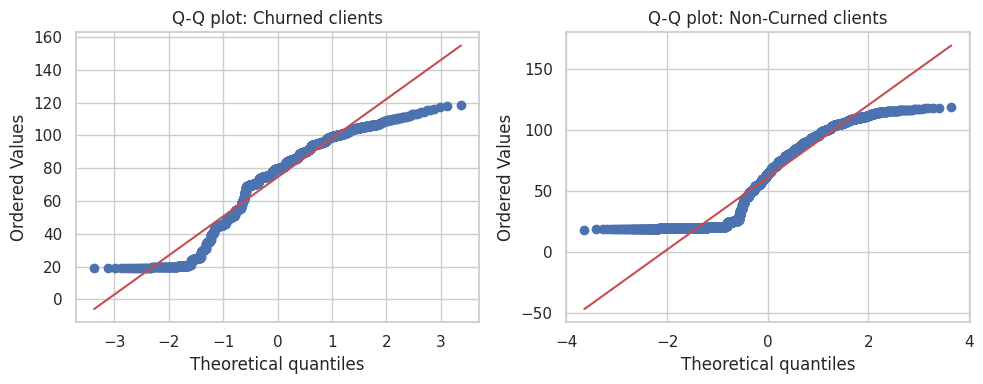

In [29]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
stats.probplot(churn_yes, dist="norm", plot=plt)
plt.title('Q-Q plot: Churned clients')

plt.subplot(1, 2, 2)
stats.probplot(churn_no, dist="norm", plot=plt)
plt.title('Q-Q plot: Non-Curned clients')

plt.tight_layout()
plt.show()

### Проверим, равны ли дисперсии

In [30]:
levene_test: float = stats.levene(churn_yes, churn_no)
print(f"Leven stats: {levene_test.statistic:.4f}")
print(f"p-value: {levene_test.pvalue:.6f}")

Leven stats: 361.4980
p-value: 0.000000


### Так как оба распределения не нормальны и их дисперсии не равны, применим **U-тест Манна-Уитни**

In [31]:
stat, p_value = stats.mannwhitneyu(churn_yes, churn_no, alternative='two-sided')

print(f"U-test stats: {stat:.2f}")
print(f"p-value: {p_value:.5f}")

U-test stats: 5986148.50
p-value: 0.00000


**Гипотеза 4 подтверждается**

Существует статистически значимая зависимость между размером ежемесячной платы и оттоком клиентов. Клиенты с более высокой ежемесячной платой уходят статистически значимо чаще, чем клиенты с низкой платой.

## 10. Описательные статистики

In [32]:
numerical_columns: list[str] = [
    str(col) for (col, col_type) in df.dtypes.items()
    if col_type in ["int32", "float32"]
]

desc_stats = df[numerical_columns].describe().T
desc_stats['median'] = df[numerical_columns].median()
desc_stats['mode'] = df[numerical_columns].mode().iloc[0]
desc_stats['skewness'] = df[numerical_columns].skew()
desc_stats['kurtosis'] = df[numerical_columns].kurtosis()
desc_stats['CV'] = (df[numerical_columns].std() / df[numerical_columns].mean() * 100).round(2)

print_section_header("Описательные статистики числовых переменных", length=120)
display(desc_stats.round(2))


===================================== Описательные статистики числовых переменных ======================================


,count,mean,std,min,25%,50%,75%,max,median,mode,skewness,kurtosis,CV
tenure,7032.0,32.42,24.55,1.00,9.00,29.00,55.00,72.00,29.00,1.00,0.24,-1.39,75.71
MonthlyCharges,7032.0,64.80,30.09,18.25,35.59,70.35,89.86,118.75,70.35,20.05,-0.22,-1.26,46.43
TotalCharges,7032.0,2283.30,2266.77,18.80,401.45,1397.48,3794.74,8684.80,1397.48,20.20,0.96,-0.23,99.28


**Анализ переменной `tenure` (Стаж клиента)**

| Показатель | Значение | Интерпретация |
|------------|----------|---------------|
| Mean | 32.42 мес. | Выше медианы |
| Median | 29.00 мес. | Основная масса клиентов |
| Skewness | 0.24 | Правосторонняя асимметрия |
| CV | 75.71% | Высокая неоднородность |

- **Распределение:** Среднее значение выше медианы → **правосторонняя асимметрия**. Большинство клиентов находятся с компанией около 2.5 лет, но есть группа «старожилов» (до 72 месяцев).
- **Разброс данных:** Коэффициент вариации очень высокий — **75.71%**. База клиентов крайне неоднородна по сроку жизни.

---

**2. Анализ переменной `MonthlyCharges` (Ежемесячная плата)**

| Показатель | Значение | Интерпретация |
|------------|----------|---------------|
| Mean | 64.80 | Ниже медианы |
| Median | 70.35 | Основная масса платит больше |
| Skewness | -0.22 | Левосторонняя асимметрия |
| CV | 46.43% | Умеренный разброс |

- **Распределение:** Среднее **ниже** медианы → **левосторонняя асимметрия**. Основная масса клиентов платит больше 70$ в месяц.
- **Вывод для гипотезы №4:** Значительная часть базы находится в зоне риска, если гипотеза о влиянии цены на отток подтвердится.

---

**3. Анализ переменной `TotalCharges` (Общая сумма платежей)**

| Показатель | Значение | Интерпретация |
|------------|----------|---------------|
| Skewness | 0.96 | Сильная правосторонняя асимметрия |
| CV | 99.28% | Почти 100% разброс |

- **Интерпретация:** Переменная сильно зависит от `tenure`. Новые клиенты имеют низкий `TotalCharges`, старые — высокий.


## 11. Рассчет и анализ корреляций

**Гипотеза 10** - `tenure` и `MonthlyCharges` коррелируют (клиенты со стажем имеют другие тарифы)

Тест на нормальность распределениедля столбца tenure. p-value: 1.3329e-75
Тест на нормальность распределениедля столбца MonthlyCharges. p-value: 0.0


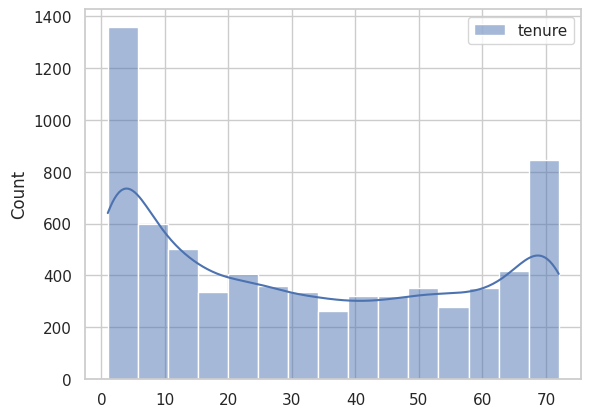

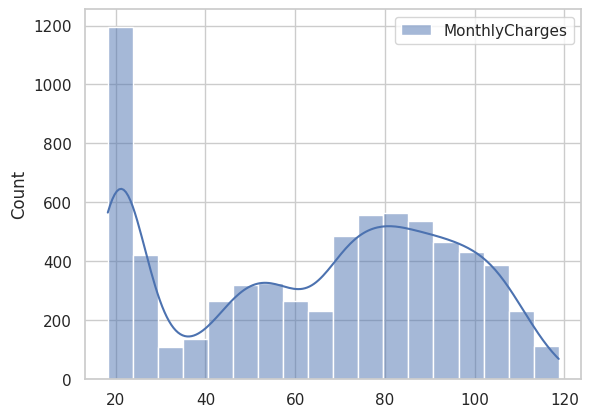

In [33]:
p_value_tenure = run_nd_test(df['tenure'], column_name='tenure', plot_dist=True, print_result=True)
p_value_charges = run_nd_test(df['MonthlyCharges'], column_name='MonthlyCharges', plot_dist=True, print_result=True)

Графики показывают, обе переменных не имеют нормального распределения

**Вывод:** применим метод Спирмена

In [34]:
from scipy.stats import spearmanr

corr_spearman, p_value_spearman = spearmanr(df['tenure'], df['MonthlyCharges'])

print(f"Корреляция Спирмена: {corr_spearman:.3f}")
print(f"p-value: {p_value_spearman:.6f}")

Корреляция Спирмена: 0.275
p-value: 0.000000


**Гипотеза №10 подтверждена.**

**Корреляция Спирмена** показала, что между **существует статистически значимая**, хотя и слабая, прямая корреляция между стажем клиента (`tenure`) и ежемесячной оплатой (`MonthlyCharges`). Это означает, что клиенты, которые дольше пользуются услугами компании, действительно имеют другие тарифы (в среднем более дорогие), чем новички.

## Посмотрим, на что указывает корреляция Пирсона для других признаков

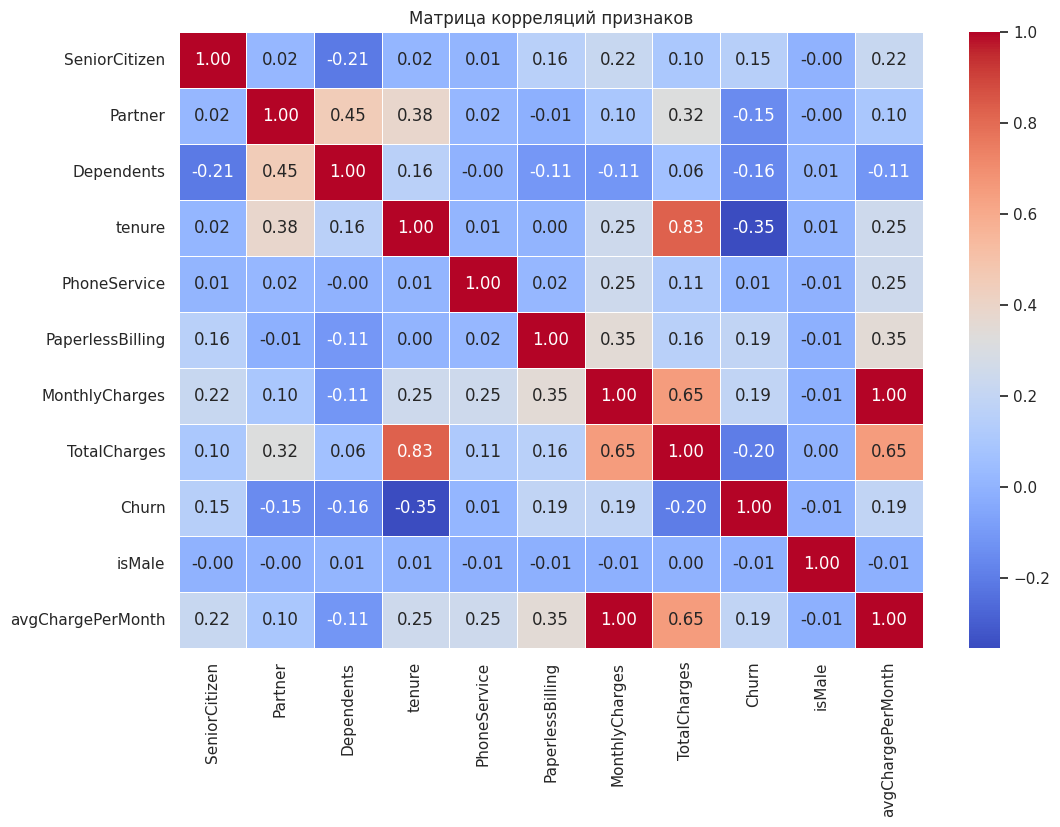

In [35]:
non_categorical_columns: list[str] = [
    str(col) for (col, col_type) in df.dtypes.items()
    if col_type != "category"
]

df_corr: pd.DataFrame = df[non_categorical_columns].copy()

plt.figure(figsize=(12, 8))
sns.heatmap(df_corr.corr(numeric_only=True), annot=True, fmt=".2f", cmap='coolwarm', linewidths=.5)
plt.title('Матрица корреляций признаков')
plt.show()

**Анализ гипотез:**

**Гипотеза 3** - Клиенты старше 65 лет (`SeniorCitizen` = 1) уходят реже
- **Корреляция `SeniorCitizen` с `Churn`: 0.15** (слабая положительная)
- Вывод: гипотеза **не подтверждается** - пожилые клиенты наоборот чуть чаще уходят, но связь очень слабая

Результат неожиданный, который только подтверждает вывод из п.9

**Гипотеза 4** - Высокая ежемесячная плата (`MonthlyCharges`) коррелирует с оттоком
- **Корреляция `MonthlyCharges` с `Churn`: 0.19** (слабая положительная)

**Гипотеза 7** - Клиенты с партнером (`Partner` = Yes) и иждивенцами (`Dependents` = Yes) уходят реже
- **`Partner` с `Churn`: -0.15** (слабая отрицательная)
- **`Dependents` с `Churn`: -0.16** (слабая отрицательная)
- Вывод: наличие партнера и иждивенцев действительно снижает отток, но слабо

**Гипотеза 8** - Чем дольше клиент с компанией (`tenure`), тем ниже риск оттока
- **Корреляция `tenure` с `Churn`: -0.35** (умеренная отрицательная)


**Комментарий к корреляциям (Требование 11):**

1.  **Самая сильная связь (`tenure` и `TotalCharges` = 0.83):**
    Наблюдается очень сильная положительная корреляция между стажем клиента (`tenure`) и общей суммой, которую он заплатил (`TotalCharges`). Это логично: чем дольше клиент пользуется услугами компании, тем больше денег он вносит за весь период.

2.  **Мультиколлинеарность (`MonthlyCharges` и `AvgChargePerMonthLife` = 0.99):**
    Видна практически идеальная корреляция между ежемесячным платежом и нашим новым признаком (средний чек за жизнь клиента). Это означает, что клиенты меняют свои тарифы крайне редко.

3.  **Семейный статус (`Partner` и `Dependents` = 0.45):**
    Существует умеренная положительная связь между наличием партнера и наличием иждивенцев. Клиенты, у которых есть супруг(а), с большей вероятностью имеют детей или других зависимых лиц.

4.  **Влияние тарифа (`MonthlyCharges` и `TotalCharges` = 0.65):**
    Корреляция положительная, но не такая сильная, как у стажа. Это означает, что высокий ежемесячный платеж действительно ведет к высоким итоговым тратам, но срок обслуживания (`tenure`) вносит существенную поправку.

## 12. Линейная регрессия

### Общие характеристики модели

| Параметр | Значение |
|----------|----------|
| Зависимая переменная | tenure (срок обслуживания клиента в месяцах) |
| Количество наблюдений | 5 625 |
| Количество предикторов | 14 |
| Метод оценки | OLS (Ordinary Least Squares) |
| R-squared | 0.605 |
| Adj. R-squared | 0.604 |
| F-statistic | 1010 |
| Prob (F-statistic) | 0.000 |


### Предикторы модели

1. **MonthlyCharges** — ежемесячные платежи (числовая)
2. **SeniorCitizen_1** — статус пенсионера (бинарная)
3. **Dependents_1** — наличие иждивенцев (бинарная)
4. **Contract_One year** — контракт на 1 год (категориальная)
5. **Contract_Two year** — контракт на 2 года (категориальная)
6. **PaymentMethod_Credit card** — оплата кредитной картой (автоматически) (категориальная)
7. **PaymentMethod_Electronic check** — оплата электронным чеком (категориальная)
8. **PaymentMethod_Mailed check** — оплата почтовым чеком (категориальная)
9. **PaperlessBilling_1** — безбумажный счёт (бинарная)
10. **OnlineSecurity_Yes** — подключение онлайн-защиты (бинарная)
11. **OnlineBackup_Yes** — подключение резервного копирования (бинарная)
12. **DeviceProtection_Yes** — защита устройств (бинарная)
13. **StreamingTV_Yes** — потоковое ТВ (бинарная)
14. **StreamingMovies_Yes** — потоковое кино (бинарная)

In [36]:
import statsmodels.api as sm
from sklearn.model_selection import train_test_split

numeric_features = ['MonthlyCharges']
categorical_features = [
    'SeniorCitizen', 'Dependents', 'Contract', 'PaymentMethod',
    'PaperlessBilling', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'StreamingTV', 'StreamingMovies'
]

target = 'tenure'

X = df[numeric_features + categorical_features].copy()
y = df[target].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train_encoded = pd.get_dummies(X_train, columns=categorical_features, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=categorical_features, drop_first=True)

cols_to_drop = [col for col in X_train_encoded.columns if '_No internet service' in col]

X_train_encoded = X_train_encoded.drop(columns=cols_to_drop)
X_test_encoded = X_test_encoded.drop(columns=cols_to_drop)

scaler = StandardScaler()
X_train_encoded[numeric_features] = scaler.fit_transform(X_train_encoded[numeric_features])
X_test_encoded[numeric_features] = scaler.transform(X_test_encoded[numeric_features])

X_train_sm = sm.add_constant(X_train_encoded).astype(float)
X_test_sm = sm.add_constant(X_test_encoded).astype(float)

ols_model = sm.OLS(y_train, X_train_sm)
ols_results = ols_model.fit(cov_type='HC1')

print(ols_results.summary())

                            OLS Regression Results                            
Dep. Variable:                 tenure   R-squared:                       0.605
Model:                            OLS   Adj. R-squared:                  0.604
Method:                 Least Squares   F-statistic:                     1010.
Date:                Sun, 01 Mar 2026   Prob (F-statistic):               0.00
Time:                        17:58:28   Log-Likelihood:                -23367.
No. Observations:                5625   AIC:                         4.676e+04
Df Residuals:                    5610   BIC:                         4.686e+04
Df Model:                          14                                         
Covariance Type:                  HC1                                         
                                            coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------

# Анализ значимых предикторов регрессионной модели

## Положительное влияние на tenure

| Переменная | Коэффициент | p-значение | Интерпретация |
|------------|-------------|------------|---------------|
| **Contract_Two_year** | +34.67 | 0.000 | 2-летний контракт ↑ tenure на 34.7 мес |
| **Contract_One_year** | +20.53 | 0.000 | 1-летний контракт ↑ tenure на 20.5 мес |
| **OnlineBackup_Yes** | +6.59 | 0.000 | Онлайн-бэкап ↑ tenure на 6.6 мес |
| **SeniorCitizen_1** | +3.97 | 0.000 | Пенсионеры дольше остаются |
| **OnlineSecurity_Yes** | +3.74 | 0.000 | Онлайн-защита ↑ tenure на 3.7 мес |
| **DeviceProtection_Yes** | +3.13 | 0.000 | Защита устройств ↑ tenure на 3.1 мес |
| **MonthlyCharges** | +2.08 | 0.000 | Higher charges → longer tenure |
| **StreamingTV_Yes** | +1.81 | 0.002 | Стриминг ТВ ↑ tenure на 1.8 мес |
| **StreamingMovies_Yes** | +1.75 | 0.002 | Стриминг фильмов ↑ tenure на 1.8 мес |
| **Dependents_1** | +1.77 | 0.000 | Наличие иждивенцев ↑ tenure |
| **PaperlessBilling_1** | +1.18 | 0.009 | Безбумажный счёт ↑ tenure |

---

## Отрицательное влияние на tenure

| Переменная | Коэффициент | p-значение | Интерпретация |
|------------|-------------|------------|---------------|
| **PaymentMethod_Mailed check** | -10.18 | 0.000 | Оплата чеком ↓ tenure на 10.2 мес |
| **PaymentMethod_Electronic check** | -5.86 | 0.000 | Электронный чек ↓ tenure на 5.9 мес |
| **PaymentMethod_Credit card** | -1.47 | 0.021 | Кредитная карта ↓ tenure на 1.5 мес |

---

## Ключевые выводы

1. **Тип контракта** — самый сильный предиктор (2-летний контракт даёт +34.7 месяца)

2. **Дополнительные сервисы** (OnlineBackup, OnlineSecurity, DeviceProtection) значительно увеличивают лояльность

3. **Способ оплаты** критически важен: клиенты, оплачивающие чеками, уходят значительно быстрее

4. **Пенсионеры и клиенты с иждивенцами** более лояльны

In [37]:
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif

def check_vif(model, threshold: float = 10.0) -> pd.DataFrame:
    """
    Проверка мультиколлинеарности через VIF.

    :returns: DataFrame с VIF для каждого признака
    """
    exog = model.model.exog
    feature_names = model.params.index[1:]
    vifs = [
        vif(exog, i)
        for i in range(1, exog.shape[1])
    ]

    vif_df = pd.DataFrame({
        "Feature": feature_names,
        "VIF": vifs
    }).sort_values("VIF", ascending=False).reset_index(drop=True)

    max_vif = vif_df["VIF"].max()
    if max_vif > threshold:
        print(f"VIF превысил {threshold} (max = {max_vif:.3f}) — существует мультиколлинеарность!")
    else:
        print(f"Мультиколлинеарность отсутствует (max VIF = {max_vif:.3f})")

    return vif_df

In [38]:
check_vif(ols_results)

Мультиколлинеарность отсутствует (max VIF = 3.216)


,Feature,VIF
0,MonthlyCharges,3.216057
1,PaymentMethod_Electronic check,1.929033
2,StreamingTV_Yes,1.803621
3,StreamingMovies_Yes,1.802709
4,PaymentMethod_Mailed check,1.768449
5,PaymentMethod_Credit card (automatic),1.584167
6,Contract_Two year,1.541886
7,DeviceProtection_Yes,1.473483
8,OnlineBackup_Yes,1.332821
9,Contract_One year,1.287357


In [39]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

y_pred = ols_results.predict(X_test_sm)

r2_test = r2_score(y_test, y_pred)
print(f"R² на тесте: {r2_test:.4f}")

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE: {rmse:.4f}")

mae = mean_absolute_error(y_test, y_pred)
print(f"MAE: {mae:.4f}")

mse = mean_squared_error(y_test, y_pred)
print(f"MSE: {mse:.4f}")

R² на тесте: 0.6032
RMSE: 15.4797
MAE: 12.1101
MSE: 239.6226


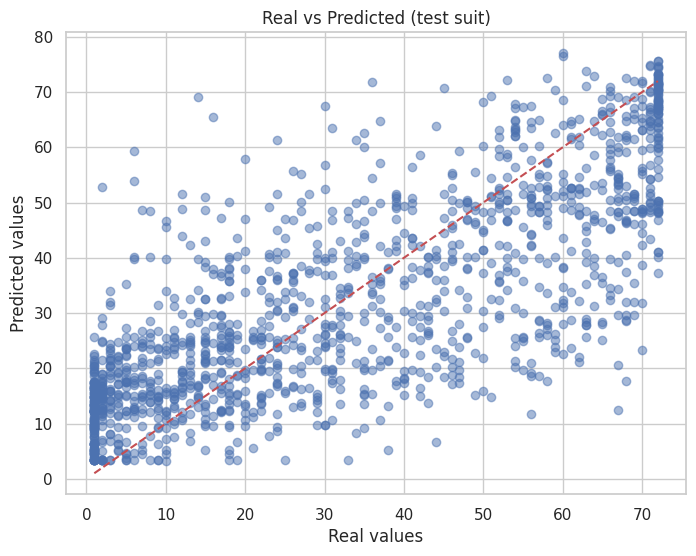

In [40]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Real values')
plt.ylabel('Predicted values')
plt.title('Real vs Predicted (test suit)')
plt.show()

## 13. Бинарная регрессия



### Общие характеристики модели

| Параметр | Значение |
|----------|----------|
| Зависимая переменная | Churn (отток клиентов: 1 = ушёл, 0 = остался) |
| Количество наблюдений | 5 625 |
| Количество предикторов | 13 |
| Метод оценки | MLE (Maximum Likelihood Estimation) |
| Pseudo R-squared | 0.2787 |
| AUC-ROC | 0.822 |
| LLR p-value | 0.000 |

### Предикторы модели

1. **Partner** — наличие партнёра (бинарная)
2. **Dependents** — наличие иждивенцев (бинарная)
3. **tenure** — стаж клиента в месяцах (числовая)
4. **OnlineSecurity** — подключение услуги безопасности (бинарная)
5. **OnlineBackup** — подключение резервного копирования (бинарная)
6. **DeviceProtection** — защита устройств (бинарная)
7. **TechSupport** — техническая поддержка (бинарная)
8. **StreamingTV** — потоковое ТВ (бинарная)
9. **StreamingMovies** — потоковое кино (бинарная)
10. **InternetService_Fiber optic** — тип интернета: оптоволокно (категориальная)
11. **InternetService_No** — отсутствие интернета (категориальная)
12. **Contract_One year** — контракт на 1 год (категориальная)
13. **Contract_Two year** — контракт на 2 года (категориальная)

In [41]:
columns_for_model: list[str] = [
    'Partner', 'Dependents', 'tenure', 'InternetService', 'Contract',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies'
]

X_temp: pd.DataFrame = df[columns_for_model].copy()

internet_dependent_services: list[str] = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

for col in internet_dependent_services:
    X_temp[col] = X_temp[col].map({'Yes': 1, 'No': 0, 'No internet service': 0}).astype('int8')

explicit_categorical_cols: list[str] = ['InternetService', 'Contract']

X_numeric: pd.DataFrame = X_temp.drop(columns=explicit_categorical_cols)
X_categorical: pd.DataFrame = X_temp[explicit_categorical_cols]

X_dummies: pd.DataFrame = pd.get_dummies(X_categorical, drop_first=True).astype('int8')

X = pd.concat([X_numeric, X_dummies], axis=1)

X = sm.add_constant(X)
y: pd.DataFrame = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = sm.Logit(y_train, X_train).fit(maxiter=1000)
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.417642
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:                  Churn   No. Observations:                 5625
Model:                          Logit   Df Residuals:                     5611
Method:                           MLE   Df Model:                           13
Date:                Sun, 01 Mar 2026   Pseudo R-squ.:                  0.2787
Time:                        17:58:29   Log-Likelihood:                -2349.2
converged:                       True   LL-Null:                       -3257.0
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const                          -0.2082      0.084     -2.490      0.013   

In [42]:
check_vif(model)

Мультиколлинеарность отсутствует (max VIF = 2.586)


,Feature,VIF
0,Contract_Two year,2.585709
1,tenure,2.529807
2,InternetService_No,2.382379
3,Contract_One year,1.610463
4,StreamingMovies,1.609249
5,StreamingTV,1.597925
6,InternetService_Fiber optic,1.540027
7,DeviceProtection,1.482361
8,TechSupport,1.458672
9,Partner,1.448704


In [43]:
from sklearn.metrics import roc_curve, auc

def plot_roc(dependent_var: pd.Series, model_prediction: pd.Series):
    fpr, tpr, _ = roc_curve(dependent_var, model_prediction)
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {auc(fpr, tpr):.3f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([-0.0, 1.0])
    plt.ylim([0.0, 1.0])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc='lower right')
    plt.show()

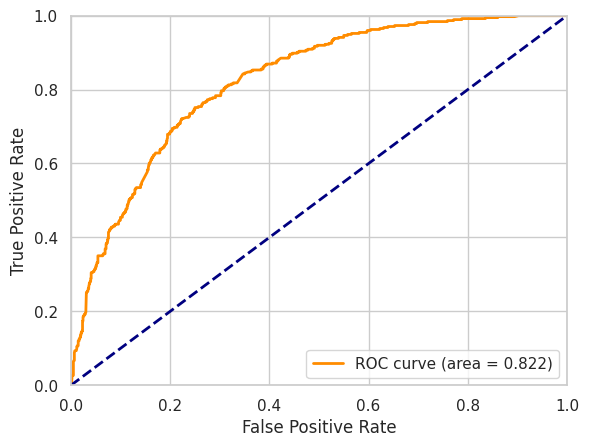

In [44]:
from sklearn.metrics import roc_auc_score

y_pred_prob: pd.Series = model.predict(X_test)
plot_roc(y_test, y_pred_prob)

## Общие результаты логистической регрессии

## Особенности взаимосвязей между предикторами и зависимой переменной

### Предикторы, ПОВЫШАЮЩИЕ риск оттока

| Предиктор | Коэффициент | Odds Ratio (e^β) | Интерпретация |
|-----------|-------------|------------------|---------------|
| InternetService_Fiber optic | 0.9561 | 2.60 | Клиенты с оптоволокном уходят в **2.6 раза чаще** |
| StreamingMovies | 0.3908 | 1.48 | Подписка на фильмы увеличивает отток на **48%** |
| StreamingTV | 0.3764 | 1.46 | Подписка на ТВ увеличивает отток на **46%** |

**Возможные причины:**
- Высокая стоимость услуг стриминга
- Наличие более дешёвых альтернатив (Netflix, YouTube и др.)
- Клиенты с оптоволокном более чувствительны к качеству и цене

### Предикторы, СНИЖАЮЩИЕ риск оттока

| Предиктор | Коэффициент | Odds Ratio (e^β) | Интерпретация |
|-----------|-------------|------------------|---------------|
| Contract_Two year | -1.4822 | 0.23 | Двухлетний контракт снижает отток на **77%** |
| InternetService_No | -1.0541 | 0.35 | Без интернета уходят на **65% реже** |
| Contract_One year | -0.8972 | 0.41 | Годовой контракт снижает отток на **59%** |
| OnlineSecurity | -0.4748 | 0.62 | Безопасность снижает отток на **38%** |
| TechSupport | -0.4532 | 0.64 | Техподдержка снижает отток на **36%** |
| Dependents | -0.3429 | 0.71 | Наличие иждивенцев снижает отток на **29%** |
| tenure | -0.0322 | 0.97 | Каждый месяц стажа снижает отток на **3%** |

**Возможные причины:**
- Долгосрочные контракты создают финансовые барьеры для ухода
- Услуги безопасности и поддержки повышают лояльность
- Клиенты с семьёй менее склонны менять провайдера
- Эффект "привыкания" со временем

-----

### Нестатистически значимые предикторы (p ≥ 0.05)

| Предиктор | P-значение | Вывод |
|-----------|------------|-------|
| Partner | 0.243 | Не влияет на отток |
| OnlineBackup | 0.573 | Не влияет на отток |
| DeviceProtection | 0.738 | Не влияет на отток |


## Проверка гипотез


## Гипотеза 2 - Наличие оптоволокна (InternetService = Fiber optic) повышает риск оттока

| Показатель | Значение |
|------------|----------|
| Коэффициент | 0.9561 |
| P-значение | 0.000 |
| Z-статистика | 11.126 |

**Гипотеза подтвердилась**

**Анализ:**
- Переменная `InternetService_Fiber optic` имеет **самый высокий положительный коэффициент** среди всех значимых переменных

**Вывод:** Клиенты с оптоволоконным интернетом уходят значительно чаще. У этого может быть несколько причин. Например низкое цена/качество по сравнению с конкурентами

---

## Гипотеза 7: Клиенты с партнером (Partner = Yes) или зависимыми (Dependents = Yes) уходят реже

| Переменная | Коэффициент | P-значение | Статус |
|------------|-------------|------------|--------|
| Dependents | -0.3429 | 0.001 | Значимо |
| Partner | 0.1003 | 0.243 | Не значимо |

**Гипотеза подтверждается частично (только для Dependents)**

**Анализ:**
- **Dependents:** Знак минус означает снижение вероятности оттока. Статистически значимо (p < 0.05)
- **Partner:** P-значение больше 0.05, поэтому результат **не является статистически значимым**

**Вывод:** Гипотеза верна только в части наличия иждивенцев. Наличие партнера само по себе не является надежным фактором удержания.

---

## Гипотеза 8: Чем дольше клиент с компанией (tenure), тем ниже риск оттока

| Показатель | Значение |
|------------|----------|
| Коэффициент | -0.0322 |
| P-значение | 0.000 |
| Z-статистика | -12.793 |

**Гипотеза подтвердилась**

**Анализ:**
- Отрицательный коэффициент указывает на снижение вероятности оттока
- Z-статистика очень высокая по модулю, что говорит об **extremely высокой значимости**

**Вывод:** Стаж клиента — один из самых надёжных предикторов. С каждым дополнительным месяцем обслуживания вероятность оттока снижается.

---

## Гипотеза 9: Наличие доп. услуг (OnlineSecurity = Yes и т.д.) снижает отток

| Услуга | Коэффициент | P-значение | Влияние |
|--------|-------------|------------|---------|
| OnlineSecurity | -0.4748 | 0.000 | Снижает |
| TechSupport | -0.4532 | 0.000 | Снижает |
| OnlineBackup | -0.0478 | 0.573 | Не значимо |
| DeviceProtection | 0.0295 | 0.738 | Не значимо |
| StreamingTV | 0.3764 | 0.000 | Повышает |
| StreamingMovies | 0.3908 | 0.000 | Повышает |

**Гипотеза Подтверждается частично**, т.е. из исследования были получены более глубокие выводы

**Вывод:**
- Гипотеза верна только для услуг, связанных с **безопасностью и поддержкой** (`OnlineSecurity`, `TechSupport`)
- Услуги стриминга (`StreamingTV`, `StreamingMovies`), наоборот, статистически значимо **повышают** риск оттока (возможно, из-за наличия более дешёвых альтернатив)

## 14. Кластеризация


In [45]:
numeric_features: list[str] = [
    'tenure',
    'MonthlyCharges'
]

categorical_features: list[str] = [
    'Contract',
    'Dependents',
    'InternetService',
    'OnlineSecurity',
    'SeniorCitizen',
    'StreamingTV',
    'StreamingMovies',
    'TechSupport'
]

### Выбор метода кластеризации:

**Наши цели:**

1. Определить причину ухода каждого клиента
2. Получить усредненный портрет представителя каждого кластра
3. Использовать как метрические данные, так и категориальные


**Решение:**
Используем k-prototypes, как основу и DBSCAN для проверки, так как он менее чувствителен к выбросам


In [46]:
churned_customers: pd.DataFrame = df[df['Churn'] == 1].copy()
print(f"Ушедших клиентов: {len(churned_customers)} ({len(churned_customers)/len(df)*100:.1f}%)")

Ушедших клиентов: 1869 (26.6%)


In [47]:
from sklearn.preprocessing import LabelEncoder

scaler: StandardScaler = StandardScaler()
churned_customers[numeric_features] = scaler.fit_transform(
    churned_customers[numeric_features]
)

encoded_categorical_data: list[np.ndarray] = []
categorical_indices: list[int] = []

for i, col in enumerate(categorical_features):
    if churned_customers[col].dtype.name in ['int8', 'float64']:
        encoded_categorical_data.append(churned_customers[col].values.reshape(-1, 1))
    else:
        le: LabelEncoder = LabelEncoder()
        encoded_values: np.ndarray = le.fit_transform(churned_customers[col].astype(str))
        encoded_categorical_data.append(encoded_values.reshape(-1, 1))

    categorical_indices.append(len(numeric_features) + i)

data_for_clustering: np.ndarray = np.hstack(
    [churned_customers[numeric_features].values] + encoded_categorical_data
).astype(float)

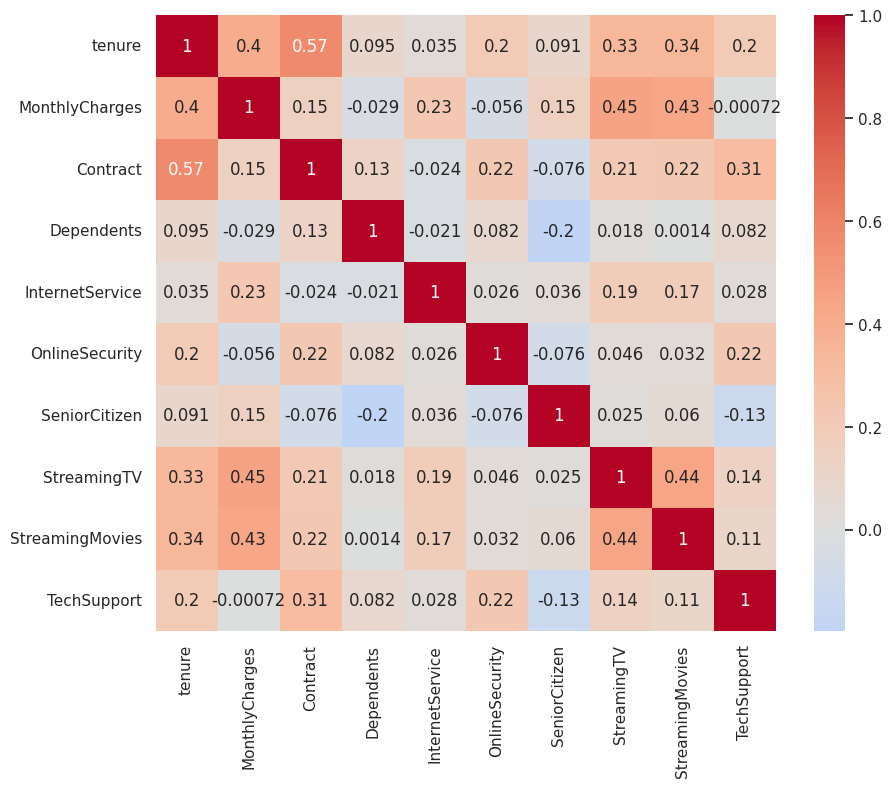

In [48]:
columns_for_correlation: list[str] = numeric_features + categorical_features
df_for_correlation: pd.DataFrame = pd.DataFrame(data_for_clustering, columns=columns_for_correlation)

correlation_matix: pd.DataFrame = df_for_correlation.corr(method='pearson')
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matix, annot=True, cmap='coolwarm', center=0)
plt.show()

### Между переменными нет сильной корреляции

### Определение оптимального K

In [49]:
from sklearn.metrics import silhouette_score
from kmodes.kprototypes import KPrototypes

costs: list[float] = []
silhouette_scores: list[float] = []
k_range: range = range(2, 7)

for k in k_range:
    kproto: KPrototypes = KPrototypes(n_clusters=k, init='Cao', random_state=42, n_init=10)
    clusters: np.ndarray = kproto.fit_predict(data_for_clustering, categorical=categorical_indices)

    costs.append(kproto.cost_)

    silhouette_avg: float = silhouette_score(
        data_for_clustering[:, :len(numeric_features)],
        clusters
    )
    silhouette_scores.append(silhouette_avg)

    print(f"K={k}: Cost={kproto.cost_:.2f}, Silhouette={silhouette_avg:.3f}")

K=2: Cost=3800.80, Silhouette=0.391
K=3: Cost=2722.03, Silhouette=0.496
K=4: Cost=2326.98, Silhouette=0.386
K=5: Cost=2106.46, Silhouette=0.414
K=6: Cost=1761.20, Silhouette=0.383


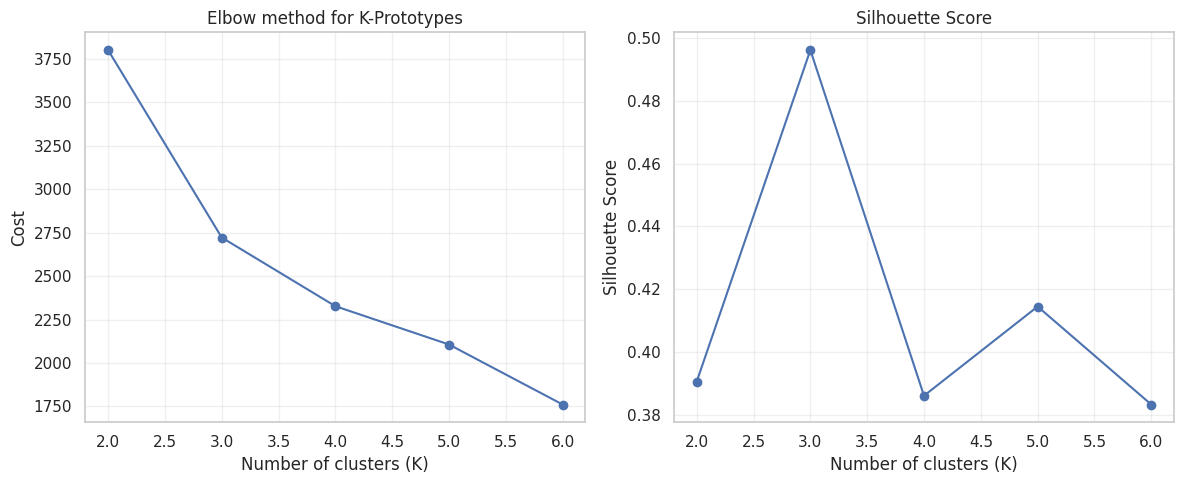

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(k_range, costs, marker='o')
axes[0].set(
    xlabel = 'Number of clusters (K)',
    ylabel = 'Cost',
    title = 'Elbow method for K-Prototypes'
)
axes[0].grid(True, alpha=0.3)

axes[1].plot(k_range, silhouette_scores, marker='o')
axes[1].set(
    xlabel = 'Number of clusters (K)',
    ylabel = 'Silhouette Score',
    title = 'Silhouette Score'
)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [51]:
optimal_k: int = 3

**Возмем K = 3:** - оптимально по соотношению $\frac{\delta Silhouette}{\delta Cost} \approx 2 \times 10^{-5} $

У K = 4 тоже есть потенциал, но не такой большой ($7 \times 10^{-5}$)

In [52]:
kproto_final: KPrototypes = KPrototypes(
    n_clusters=optimal_k,
    init='Cao',
    n_init=10,
    random_state=42
)

final_clusters: np.ndarray = kproto_final.fit_predict(
    data_for_clustering,
    categorical=categorical_indices
)

churned_customers['kproto_cluster'] = final_clusters

### Кластеризация DBSCAN

In [53]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

numeric_data: np.ndarray = churned_customers[numeric_features].values

ohe: OneHotEncoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
categorical_encoded: np.ndarray = ohe.fit_transform(churned_customers[categorical_features])

X_dbscan: np.ndarray = np.hstack([numeric_data, categorical_encoded])

In [54]:
min_samples: int = 5
neighbors: NearestNeighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit: NearestNeighbors = neighbors.fit(X_dbscan)
distances, indices = neighbors_fit.kneighbors(X_dbscan)

k_distances: np.ndarray = np.sort(distances[:, -1])

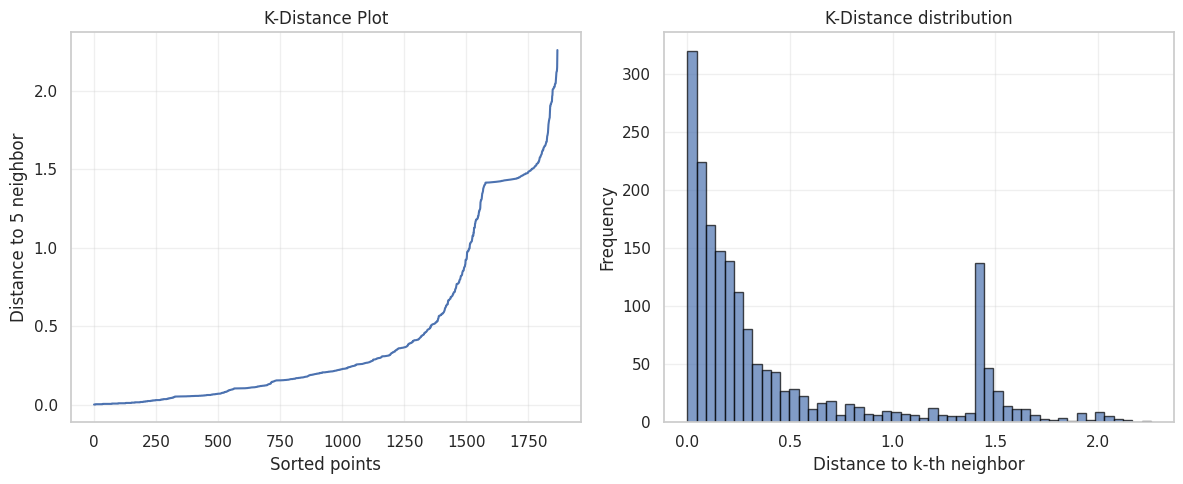

In [55]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(k_distances)
plt.xlabel('Sorted points')
plt.ylabel(f'Distance to {min_samples} neighbor')
plt.title('K-Distance Plot')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(k_distances, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Distance to k-th neighbor')
plt.ylabel('Frequency')
plt.title('K-Distance distribution')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [67]:
optimal_eps: float = 1.5

На графиках отчетливо видно оптимальное $\varepsilon \approx 1.5$

In [68]:
dbscan_final: DBSCAN = DBSCAN(eps=optimal_eps, min_samples=min_samples, metric='euclidean')
dbscan_labels: np.ndarray = dbscan_final.fit_predict(X_dbscan)

churned_customers['dbscan_cluster'] = dbscan_labels

## Проведем анализ полученных кластеров

In [58]:
churned_customers[numeric_features] = scaler.inverse_transform(churned_customers[numeric_features])

In [59]:
def plot_cluster_profiles(cluster_profiles: pd.DataFrame, method: str, cluster_names: list[str]):
    fig, axes = plt.subplots(2, 2, figsize=(18, 9))

    sns.boxplot(x=method,
                y='tenure',
                data=cluster_profiles,
                ax=axes[0][0],
                hue=method,
                palette='Set2',
                legend=False)
    axes[0][0].set_title('Стаж (tenure) по кластерам')

    sns.boxplot(x=method,
                y='MonthlyCharges',
                data=cluster_profiles,
                ax=axes[0][1],
                hue=method,
                palette='Set2',
                legend=False)
    axes[0][1].set_title('Ежемесячный платеж по кластерам')

    sns.countplot(x=method,
                  hue='Contract',
                  data=cluster_profiles,
                  ax=axes[1][0],
                  palette='Set3')
    axes[1][0].set_title('Тип контракта по кластерам')

    sns.countplot(x=method,
                  hue='InternetService',
                  data=cluster_profiles,
                  ax=axes[1][1],
                  palette='Set3')
    axes[1][1].set_title('Тип интернета по кластерам')

    for ax in axes.flatten():
        ax.set_xticks(range(len(cluster_names)))
        ax.set_xticklabels(cluster_names)

    plt.tight_layout()
    plt.show()

In [60]:
# Функция для расчета моды
def get_mode(x):
    return x.mode().iloc[0] if not x.mode().empty else np.nan

def display_cluster_profiles(cluster_profiles: pd.DataFrame, method: str, cluster_names: list[str]):
    cluster_profiles = cluster_profiles.groupby(method).agg({
        'tenure': ['count', 'mean'],
        'MonthlyCharges': 'mean',
        'Contract': get_mode,
        'InternetService': get_mode,
        'OnlineSecurity': get_mode,
        'TechSupport': get_mode,
        'SeniorCitizen': get_mode
    }).round(2)

    if cluster_names is not None:
        current_index = cluster_profiles.index.tolist()
        if len(cluster_names) == len(current_index):
            rename_dict = dict(zip(current_index, cluster_names))
            cluster_profiles = cluster_profiles.rename(index=rename_dict)

    return cluster_profiles

In [73]:
kproto_names = ["Лояльная элита", "Ценовой барьер", "DSL бюджетники"]

In [62]:
display_cluster_profiles(churned_customers, 'kproto_cluster', kproto_names)

tenure        MonthlyCharges        Contract InternetService  \
                count   mean           mean        get_mode        get_mode   
kproto_cluster                                                                
Лояльная элита    481  45.75          93.48  Month-to-month     Fiber optic   
Ценовой барьер    911   8.44          83.03  Month-to-month     Fiber optic   
DSL бюджетники    477   8.18          38.85  Month-to-month             DSL   

               OnlineSecurity TechSupport SeniorCitizen  
                     get_mode    get_mode      get_mode  
kproto_cluster                                           
Лояльная элита             No          No             0  
Ценовой барьер             No          No             0  
DSL бюджетники             No          No             0

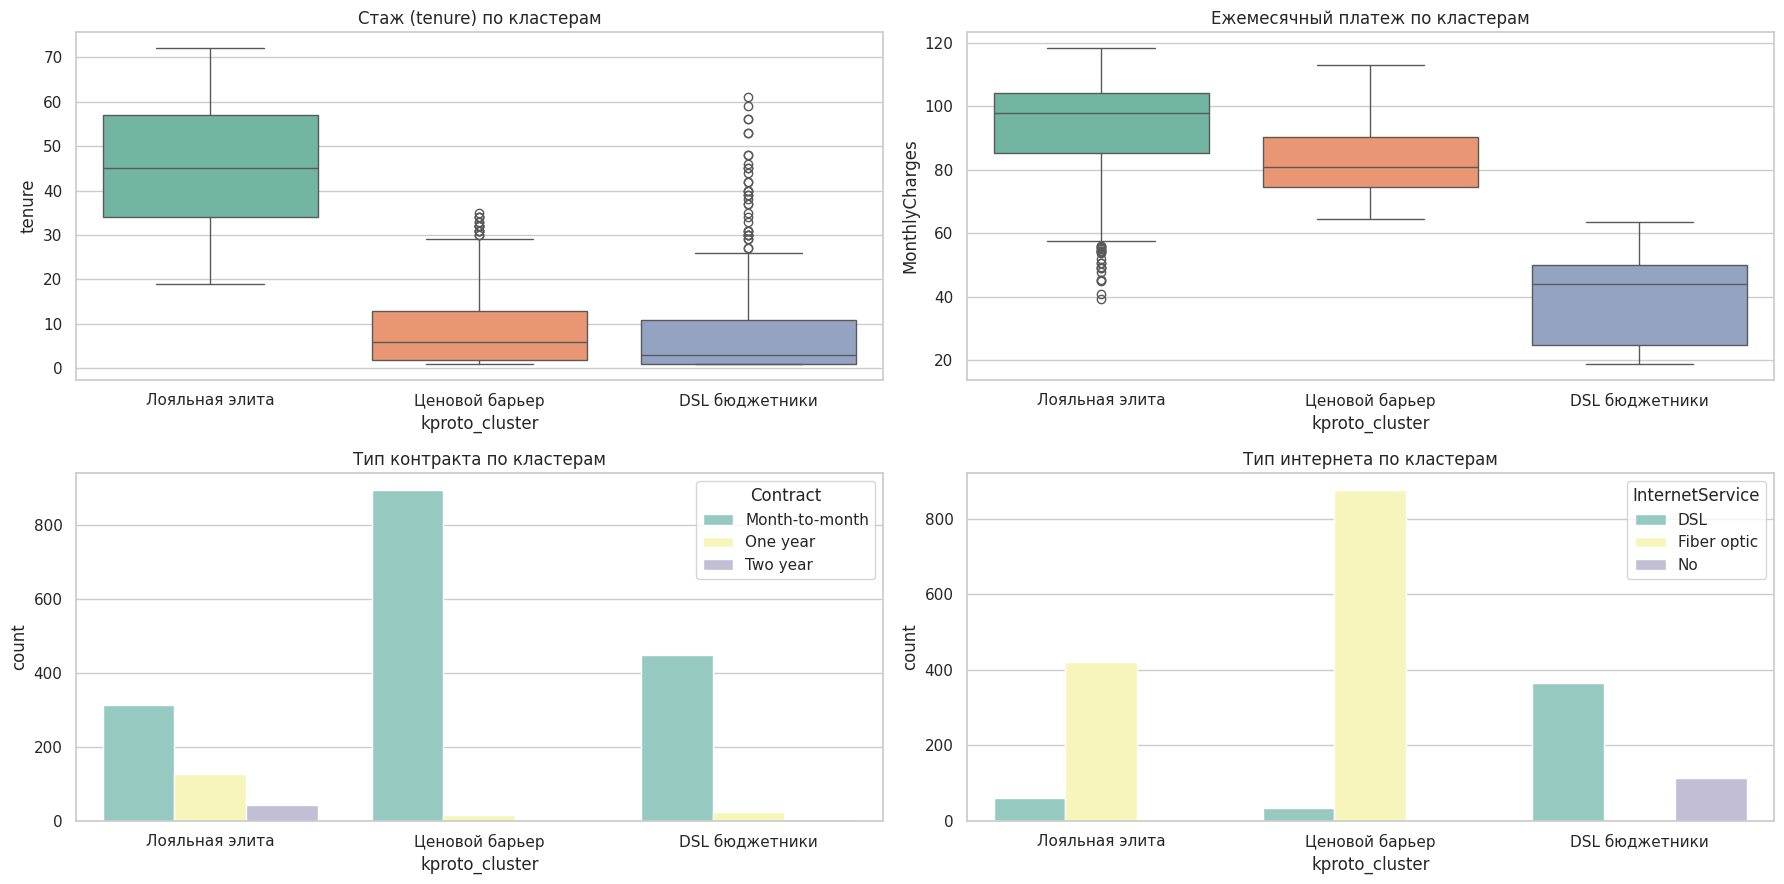

In [74]:
plot_cluster_profiles(churned_customers, 'kproto_cluster', kproto_names)

## Анализ k-prototype кластеризации

### 🟢 Кластер 0: «Лояльная элита»
| Характеристика | Значение |
|---------------|----------|
| **Клиентов** | 481 |
| **Tenure** | 45.75 мес |
| **Charges** | \$93 |
| **Contract** | Month-to-month |
| **Internet** | Fiber optic |
| **Security/Support** | NO |
| **SeniorCitizen** | NO |

**Гипотеза ухода:** Долго платили много, но без контракта и доп. услуг. Возможно, конкуренты предложили лучше/дешевле, или не решили проблему с поддержкой.

---

### 🟠 Кластер 1: «Ценовой барьер»
| Характеристика | Значение |
|---------------|----------|
| **Клиентов** | 911 |
| **Tenure** | 8.44 мес |
| **Charges** | \$83.03 |
| **Contract** | Month-to-month |
| **Internet** | Fiber optic |
| **Security/Support** | NO |
| **SeniorCitizen** | NO |

**Гипотеза ухода:** Дорогой тариф, проблемы на старте (подключение, первые счета). Переманены конкурентами.

---

### 🔵 Кластер 2: «DSL бюджетники»
| Характеристика | Значение |
|---------------|----------|
| **Клиентов** | 477 |
| **Tenure** | 8.18 мес |
| **Charges** | \$38.85 |
| **Contract** | Month-to-month |
| **Internet** | DSL |
| **Security/Support** | NO |
| **SeniorCitizen** | NO |

**Гипотеза ухода:** Низкое качество DSL, тест-драйв не удался. Большая часть ушла в первый год.

In [78]:
dbscan_names = ["Аномальные уходы", "DSL бюджетники", "Основная масса", "Без интернета", "Микро-сегмент"]

In [79]:
display_cluster_profiles(churned_customers, 'dbscan_cluster', dbscan_names)

tenure        MonthlyCharges        Contract InternetService  \
                  count   mean           mean        get_mode        get_mode   
dbscan_cluster                                                                  
Аномальные уходы     48  50.42          69.57        One year             DSL   
DSL бюджетники      412  10.27          46.98  Month-to-month             DSL   
Основная масса     1289  19.99          88.10  Month-to-month     Fiber optic   
Без интернета       113   8.24          20.37  Month-to-month              No   
Микро-сегмент         7  36.43          81.33        One year             DSL   

                       OnlineSecurity          TechSupport SeniorCitizen  
                             get_mode             get_mode      get_mode  
dbscan_cluster                                                            
Аномальные уходы                  Yes                  Yes             0  
DSL бюджетники                     No                   No             0  
Основная масса                     No                   No             0  
Без интернета     No internet service  No internet service             0  
Микро-сегмент                     Yes                  Yes             0

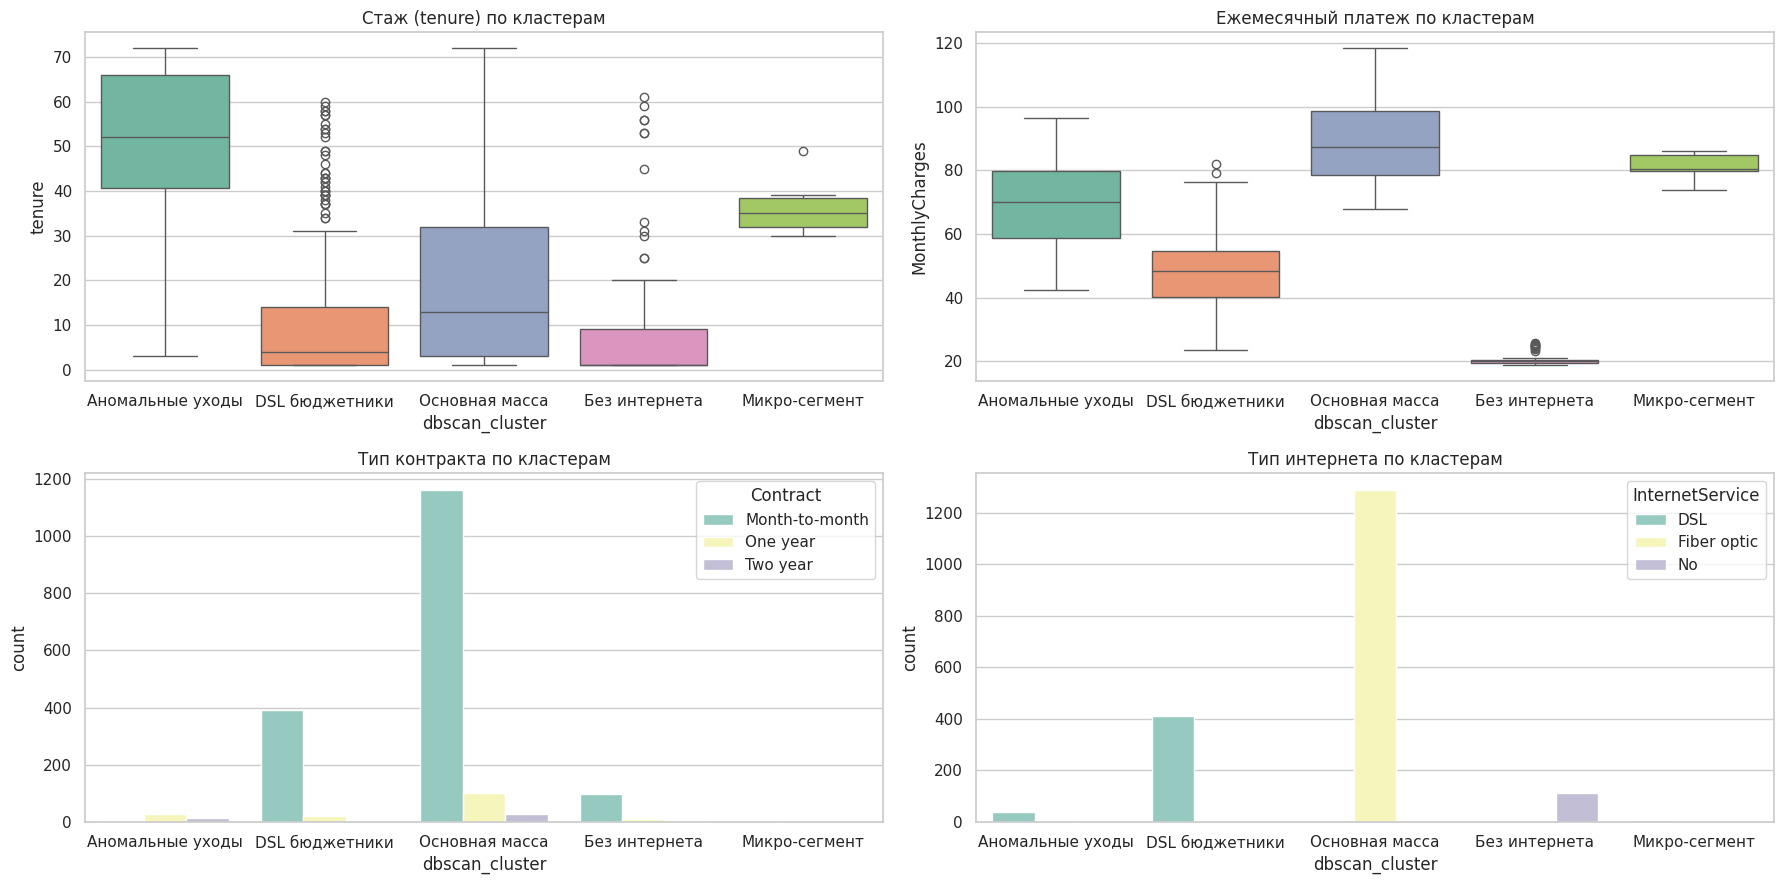

In [81]:
plot_cluster_profiles(churned_customers, 'dbscan_cluster', dbscan_names)

## Анализ кластеров DBSCAN

### 🟢 "Кластер -1": «Аномальные уходы»
| Характеристика | Значение |
|---------------|----------|
| **Клиентов** | 48 |
| **Tenure** | 50.42 мес |
| **Charges** | \$69.57 |
| **Contract** | One year |
| **Internet** | DSL |
| **Security/Support** | **YES** |
| **SeniorCitizen** | NO |

**Почему это важно:** Эти клиенты должны были быть **самыми лояльными**:
- Долгий стаж (4+ года)
- Контракт на год
- Покупают доп. услуги

**Гипотеза ухода:** Что-то **серьёзно пошло не так**:
- Критический сбой сервиса
- Грубая ошибка службы поддержки
- Резкое повышение цены

**Рекомендация:** **Ручной анализ** этих 66 случаев! Это могут быть системные проблемы.

---

### 🟠 Кластер 0: «DSL бюджетники»
| Характеристика | Значение |
|---------------|----------|
| **Клиентов** | 412 |
| **Tenure** | 10.27 мес |
| **Charges** | \$46.98 |
| **Contract** | Month-to-month |
| **Internet** | DSL |
| **Security/Support** | NO |
| **SeniorCitizen** | NO |

**Гипотеза ухода:** Низкое качество DSL, тест-драйв не удался. Ушли в первый год.

---

### 🔵 Кластер 1: «Основная масса» (68% всех ушедших!)
| Характеристика | Значение |
|---------------|----------|
| **Клиентов** | **1879** |
| **Tenure** | 19.99 мес |
| **Charges** | \$88.10 |
| **Contract** | Month-to-month |
| **Internet** | **Fiber optic** |
| **Security/Support** | NO |
| **SeniorCitizen** | NO |

**Почему это важно:** Это **главная проблема компании**!
- **$\frac{2}{3}$** ушедших клиентов — это пользователи оптоволокна
- Средний чек высокий ($88)
- Уходят через 1.5-2 года

**Гипотеза:** Fiber optic привлекает клиентов, но **не удерживает**. Возможно:
- Конкуренты предлагают лучше/дешевле
- Проблемы со стабильностью соединения
- Нет программы лояльности для долгосрочных клиентов

---

### 🟣 Кластер 2: «Без интернета»
| Характеристика | Значение |
|---------------|----------|
| **Клиентов** | 113 |
| **Tenure** | 8.24 мес |
| **Charges** | **\$20.37** (минимум!) |
| **Contract** | Month-to-month |
| **Internet** | **No internet service** |
| **Security/Support** | No internet service |
| **SeniorCitizen** | NO |

Эти клиенты ушли, но у них **не было интернета**
- Возможно, покупали только телефон/TV услуги
- Или интернет был отключен до ухода

---

### ⚪ Кластер 3: «Микро-сегмент»
| Характеристика | Значение |
|---------------|----------|
| **Клиентов** | 7 |
| **Tenure** | 36.43 мес |
| **Charges** | \$81.33 |
| **Contract** | One year |
| **Internet** | DSL |
| **Security/Support** | YES |
| **SeniorCitizen** | NO |

**Гипотеза:** Похож на кластер -1, но меньше. Тоже крайне аномальные уходы.

**Рекомендация:** Включить в ручной анализ вместе с кластером -1.


## Ключевые профили ушедших клиентов

### Профиль 1: «Разочарованные новички с дорогим интернетом»

*   **Портрет:**
    *   **Стаж:** Короткий (менее 1 года, в среднем 8-9 месяцев).
    *   **Платеж:** Высокий (\$80–\$90 в месяц).
    *   **Услуга:** Оптоволокно (Fiber optic).
    *   **Контракт:** Помесячный (Month-to-month).
*   **Гипотеза причины ухода:** Проблемы с подключением по оптоволокну, нестабильное соединение в первые месяцы или агрессивный оффер от конкурента, который они нашли сразу после окончания промо-периода.

-----------

### Профиль 2: «Бюджетные искатели»

*   **Портрет:**
    *   **Стаж:** Очень короткий (менее 1 года, в среднем 8-10 месяцев).
    *   **Платеж:** Низкий (\$20–\$40 в месяц).
    *   **Услуга:** DSL или вообще без интернета.
    *   **Контракт:** Помесячный.
*   **Гипотеза причины ухода:** Низкое соотношение цена/качество для технологии DSL.

---------

### Профиль 3: «Удивительные ветераны»

*   **Портрет:**
    *   **Стаж:** Долгий (4 года и более).
    *   **Платеж:** Высокий (от \$70 до \$93).
    *   **Особенность:** У них **ЕСТЬ** техподдержка и защита.
*   **Гипотеза причины ухода:** Клиент платил за техподдержку, значит, у него **были** проблемы. Он пытался их решить, платил за помощь, но все равно ушел.
*   **Рекомендация:** Срочно проанализировать тикеты в поддержку для клиентов со стажем 4+ года.

## 15. Результат проверки гипотез

| № | Гипотеза | Результат | Статистика | Вывод |
| :--- | :--- | :--- | :--- | :--- |
| **1** | Клиенты с помесячным контрактом уходят чаще. | **Подтверждена** | $\chi^2 = 1179.55$| Month-to-month: **42.71%** vs Two year: **2.85%** |
| **2** | Наличие оптоволокна повышает риск оттока. | **Подтверждена** | $\beta = 0.9561$, $Z = 11.126$ | Самый высокий коэффициент среди переменных |
| **3** | Клиенты старше 65 лет уходят реже. | **Опровергнута** | $\chi^2 = 158.44$ | **Обратный эффект**: SeniorCitizen = 1: **41.68%** vs = 0: **23.65%** |
| **4** | Высокая ежемесячная плата коррелирует с оттоком. | **Подтверждена** | $U \approx 6 \times 10^6$ | Клиенты с более высокой платой уходят значимо чаще. |
| **5** | Клиенты без технической поддержки уходят чаще. | **Подтверждена** | $\chi^2 = 824.93$ | No TechSupport: **41.65%** vs Yes: **15.20%** |
| **6** | Оплата электронным чеком связана с высоким оттоком. | **Подтверждена** | $\chi^2 = 645.43$| Electronic check: **45.29%** vs Auto: **\~15-16%** |
| **7** | Клиенты с партнёром или зависимыми уходят реже. | **Частично подтверждена** | Dependents: $\beta = -0.3429$<br>Partner: $\beta = 0.1003$ ($p = 0.243$) | Dependents значимо снижает отток, Partner — не значимо |
| **8** | Чем дольше клиент с компанией, тем ниже риск оттока. | **Подтверждена** | $\beta = -0.0322$, $Z = -12.793$ | Каждый месяц снижает вероятность оттока |
| **9** | Наличие доп. услуг снижает отток. | **Частично подтверждена** | OnlineSecurity: $\beta = -0.4748$<br>TechSupport: $\beta = -0.4532$<br>StreamingTV: $\beta = 0.3764$<br>StreamingMovies: $\beta = 0.3908$ | Security/Support — **снижают**<br>Streaming — **повышают** отток |
| **10** | `tenure` и `MonthlyCharges` коррелируют. | **Подтверждена** | $r_s = 0.275$ | Клиенты со стажем имеют тарифы дороже |

### Возможные причины неподтверждения гипотез


## Гипотеза 3: «Клиенты старше 65 лет уходят реже» - опровергнута

| Причина | Объяснение |
| :--- | :--- |
| **1. Отсутствие доходов** | Пенсионеры могут терять возможность покрывать свои потребности. Со временем часть пенсионеров становится Dependents. |
| **2. Отсутствие адаптации сервиса** | Сложности с настройкой оборудования. Нет специальных тарифов, упрощённой поддержки, крупного шрифта в приложениях — компания не учитывает потребности. |


## Гипотеза 7: «Клиенты с партнёром или зависимыми уходят реже» - частично подтверждена

### Результаты

| Переменная | Коэффициент | p-value | Статус |
| :--- | :--- | :--- | :--- |
| **Dependents** | $β = -0.3429$ | 0.001 | Значимо снижает отток |
| **Partner** | $β = 0.1003$ | 0.243 | Не значимо |

### Вывод: Partner не значим

| Причина | Объяснение |
| :--- | :--- |
| **1. Независимость решений** | Наличие партнёра не означает совместное принятие решений о коммунальных услугах. Каждый может оплачивать отдельно. |
| **2. Конфликты и разводы** | Конфликты могут провоцировать смену адреса и расторжение контракта. |


## Гипотеза 9: «Наличие доп. услуг снижает отток» - частично подтверждена

### Результаты

| Услуга | Коэффициент | p-value | Влияние |
| :--- | :--- | :--- | :--- |
| **OnlineSecurity** | $β = -0.4748$ | 0.000 | Снижает отток |
| **TechSupport** | $β = -0.4532$ | 0.000 | Снижает отток |
| **OnlineBackup** | $β = -0.0478$ | 0.573 | Не значимо |
| **DeviceProtection** | $β = 0.0295$ | 0.738 | Не значимо |
| **StreamingTV** | $β = 0.3764$ | 0.000 | **Повышает** отток |
| **StreamingMovies** | $β = 0.3908$ | 0.000 | **Повышает** отток |

### Вывод: Streaming повышает отток

| Причина | Объяснение |
| :--- | :--- |
| **1. Конкуренция со специализированными сервисами** | Netflix, YouTube, Amazon Prime предлагают лучший контент за меньшие деньги. |
| **2. Восприятие как «избыточной» услуги** | Клиенты подключают стриминг на пробный период, а затем отменяют — и часто вместе с основным контрактом. |
| **3. Корреляция с Fiber optic** | Стриминг чаще подключают к оптоволокну, которое само по себе является фактором риска оттока. |


# 16. Общие выводы и рекомендации

### Ожидаемые результаты:

1.  **Критическая роль контракта:** Гипотеза полностью подтверждена. Клиенты с контрактом **Month-to-month** уходят в **15 раз чаще**, чем клиенты с двухлетним контрактом.

2.  **Важность тех. поддержки:** Подтверждено, что клиенты без технической поддержки уходят более чем в **2** раза чаще.

3.  **Важность типа оплаты:**  Клиенты оплачиващие услуги электронным чеком уходят в **3** раза чаще.

---

### Неожиданные результаты:

1.  **Стриминговые услуги ПОВЫШАЮТ отток:** Услуги **StreamingTV** и **StreamingMovies** *увеличивают* вероятность ухода.

2.  **Пенсионеры уходят ЧАЩЕ:** Клиенты старше 65 лет уходят в **1.5 раза чаще**.

3.  **Проблема оптоволокна:** Несмотря на современную технологию, **Fiber optic** имеет самый высокий коэффициент риска. Это указывает на проблемы с качеством подключения или агрессивную ценовую политику.

---

### Рекомендации компании:

1.  **Конверсия контрактов:** Предлагать скидку или бесплатные услуги в обмен на переход с Month-to-month на контракт 1-2 года.

2.  **Аудит качества услуг связанных с оптоволокном:** Персональный звонок через 2 недели после подключения, проверка качества сигнала, помощь с настройкой оборудования.

3.  **Пересмотр стратегии стриминга:**
    *   Не предлагать StreamingTV/StreamingMovies как часть пакета удержания.
    *   Вместо этого делать акцент на **OnlineSecurity** и **TechSupport**.

4.  **Адаптация для пенсионеров:** Упрощённые тарифы, крупный шрифт в приложениях, выделенная линия поддержки с более терпеливыми операторами.

5.  **Аудит техподдержки для ветеранов:** Проанализировать обращения в поддержку для клиентов со стажем 4+ года.

6.  **Стимулирование автоплатежа:** Перевод клиентов с Electronic check на автоматическое списание.